In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import cmocean as cm
from datetime import timedelta, timezone
import textalloc as ta
from sklearn.linear_model import HuberRegressor
from matplotlib import gridspec


from jiflr import ROOT
from jiflr.data import select_sensors, merge_sensor_datasets
from jiflr.utils import lapse_rate_ufunc, butterworth_filter

In [2]:
# Load 2m sensors (same as before)
ds_2m = xr.open_dataset(ROOT / "data/2025/processed/lvl1/lvl1_on_ice.nc")
ds_2m = select_sensors(ds_2m, height="2m", shielding="shielded")

ds_2m_intensive = xr.open_dataset(ROOT / "data/2025/processed/lvl1/lvl1_on_ice_intensive.nc")
ds_2m_intensive = select_sensors(ds_2m_intensive, height="2m", shielding="shielded")

ds_2m = merge_sensor_datasets(ds_2m, ds_2m_intensive)

# Load 1m sensors
ds_1m = xr.open_dataset(ROOT / "data/2025/processed/lvl1/lvl1_on_ice.nc")
ds_1m = select_sensors(ds_1m, height="1m", shielding="shielded")

ds_1m_intensive = xr.open_dataset(ROOT / "data/2025/processed/lvl1/lvl1_on_ice_intensive.nc")
ds_1m_intensive = select_sensors(ds_1m_intensive, height="1m", shielding="shielded")

ds_1m = merge_sensor_datasets(ds_1m, ds_1m_intensive)

# Resample both to 15 min
da_2m = ds_2m.temp_c.resample(datetime="15min").mean(skipna=True).dropna(dim="datetime", how="all")
da_1m = ds_1m.temp_c.resample(datetime="15min").mean(skipna=True).dropna(dim="datetime", how="all")

# Align on shared sites and times, then mask where 1m < 2m
da_1m_aligned, da_2m_aligned = xr.align(da_1m, da_2m, join="inner")
mask_1m_colder = da_1m_aligned < da_2m_aligned
# Add mask as a coordinate on the 2m DataArray
da = da_2m.assign_coords(inversion=mask_1m_colder.reindex_like(da_2m))

In [3]:
P3_SITES = [
    #"A04",
    "A05",
    "Windward2",
    "A06",
    "Windward1",
    "F03",
    "F05",
    "F06",
    "A07",
    "Divide",
    "A08",
    "Lee1",
    #"A10",
    "Lee2",
]


def get_period_arrays(da, period):
    """Return (da_full, da_day) for a given period name."""
    masks = {
        "p1": None,
        "p2": (~da.site_id.str.startswith("B")) & (~da.site_id.isin(["G04"])),
        "p3": da.site_id.isin(P3_SITES),
    }
    mask = masks[period]
    if mask is None:
        return da
    return da.sel(sensor_idx=mask)


def _period_date_info(da_period):
    has_data = da_period.notnull().all(dim="sensor_idx")
    da_overlap = da_period.sel(datetime=has_data)
    t0 = pd.Timestamp(da_overlap.datetime.values[0])
    t1 = pd.Timestamp(da_overlap.datetime.values[-1])
    n_days = len(np.unique(da_overlap.datetime.dt.date.values))
    return t0.strftime("%Y-%m-%d"), t1.strftime("%Y-%m-%d"), n_days


for period in ["p1", "p2", "p3"]:
    da_sub = get_period_arrays(da, period)
    print(_period_date_info(da_sub))

('2025-06-23', '2025-07-06', 14)
('2025-06-23', '2025-07-14', 22)
('2025-06-22', '2025-07-26', 35)


In [4]:
continental_sites = ["Divide", "Lee1", "Lee2", "A08", "A10"]
maritime_sites = ["A04", "A05", "Windward2", "A06", "Windward1", "A07", "Divide"]
# maritime_sites = [
#     site_id for site_id in da.site_id.values if site_id not in continental_sites
# ]

rows = []
for period in ["p1", "p2", "p3"]:
    da_sub = get_period_arrays(da, period)

    n_maritime = int(da_sub.site_id.isin(maritime_sites).sum())
    n_continental = int(da_sub.site_id.isin(continental_sites).sum())
    min_elev = float(da_sub.elevation.min())
    max_elev = float(da_sub.elevation.max())

    start, end, n_days = _period_date_info(da_sub)

    rows.append(
        {
            "period": period,
            "maritime_sites": n_maritime,
            "continental_sites": n_continental,
            "start_date": start,
            "end_date": end,
            "n_days": n_days,
            "min_elevation": min_elev,
            "max_elevation": max_elev,
        }
    )

df = pd.DataFrame(rows).set_index("period")
print(df)

        maritime_sites  continental_sites  start_date    end_date  n_days  \
period                                                                      
p1                   7                  5  2025-06-23  2025-07-06      14   
p2                   7                  5  2025-06-23  2025-07-14      22   
p3                   6                  4  2025-06-22  2025-07-26      35   

        min_elevation  max_elevation  
period                                
p1             1091.0         1983.0  
p2             1109.0         1983.0  
p3             1300.0         1983.0  


In [5]:
da = get_period_arrays(da, "p3")
da = da.dropna(dim="datetime", how="any")

# Create masks for maritime and continental sites
maritime_mask = da.site_id.isin(maritime_sites).values
continental_mask = da.site_id.isin(continental_sites).values

print("Calculating maritime lapse rates...")
# Apply to maritime sites
maritime_slopes, maritime_intercepts = xr.apply_ufunc(
    lapse_rate_ufunc,
    da,
    da.elevation,
    maritime_mask,
    input_core_dims=[["datetime", "sensor_idx"], ["sensor_idx"], []],
    output_core_dims=[["datetime"], ["datetime"]],
    output_dtypes=[float, float],
    dask="forbidden",  # Disable dask for simplicity
)

print("Calculating continental lapse rates...")
# Apply to continental sites
continental_slopes, continental_intercepts = xr.apply_ufunc(
    lapse_rate_ufunc,
    da,
    da.elevation,
    continental_mask,
    input_core_dims=[["datetime", "sensor_idx"], ["sensor_idx"], []],
    output_core_dims=[["datetime"], ["datetime"]],
    output_dtypes=[float, float],
    dask="forbidden",  # Disable dask for simplicity
)

print("Lapse rate calculation completed!")

# %%
# Add the calculated lapse rates and intercepts as data variables to the dataset
print("Adding lapse rate variables to dataset...")

# Create DataArrays with proper coordinates and attributes
maritime_lapse_rate = xr.DataArray(
    maritime_slopes,
    coords={"datetime": da.datetime},
    dims=["datetime"],
    name="maritime_lapse_rate",
    attrs={
        "long_name": "Maritime sites temperature lapse rate",
        "units": "degrees_C/m",
        "description": f"Linear regression slope for temperature vs elevation for maritime sites: {maritime_sites}",
        "sites_included": ", ".join(maritime_sites),
        "calculation_method": "hourly linear regression using scipy.stats.linregress",
    },
)

maritime_intercept = xr.DataArray(
    maritime_intercepts,
    coords={"datetime": da.datetime},
    dims=["datetime"],
    name="maritime_intercept",
    attrs={
        "long_name": "Maritime sites temperature lapse rate intercept",
        "units": "degrees_C",
        "description": f"Linear regression intercept for temperature vs elevation for maritime sites: {maritime_sites}",
        "sites_included": ", ".join(maritime_sites),
        "calculation_method": "hourly linear regression using scipy.stats.linregress",
    },
)

continental_lapse_rate = xr.DataArray(
    continental_slopes,
    coords={"datetime": da.datetime},
    dims=["datetime"],
    name="continental_lapse_rate",
    attrs={
        "long_name": "Continental sites temperature lapse rate",
        "units": "degrees_C/m",
        "description": f"Linear regression slope for temperature vs elevation for continental sites: {continental_sites}",
        "sites_included": ", ".join(continental_sites),
        "calculation_method": "hourly linear regression using scipy.stats.linregress",
    },
)

continental_intercept = xr.DataArray(
    continental_intercepts,
    coords={"datetime": da.datetime},
    dims=["datetime"],
    name="continental_intercept",
    attrs={
        "long_name": "Continental sites temperature lapse rate intercept",
        "units": "degrees_C",
        "description": f"Linear regression intercept for temperature vs elevation for continental sites: {continental_sites}",
        "sites_included": ", ".join(continental_sites),
        "calculation_method": "hourly linear regression using scipy.stats.linregress",
    },
)

# Add to the hourly dataset
ds = da.to_dataset()
ds["maritime_lapse_rate"] = maritime_lapse_rate * 1000
ds["maritime_intercept"] = maritime_intercept * 1000
ds["continental_lapse_rate"] = continental_lapse_rate * 1000
ds["continental_intercept"] = continental_intercept * 1000


print("Lapse rate variables added successfully!")
print(f"Dataset variables: {list(ds.data_vars)}")


Calculating maritime lapse rates...
Calculating continental lapse rates...
Lapse rate calculation completed!
Adding lapse rate variables to dataset...
Lapse rate variables added successfully!
Dataset variables: ['temp_c', 'maritime_lapse_rate', 'maritime_intercept', 'continental_lapse_rate', 'continental_intercept']
Lapse rate calculation completed!
Adding lapse rate variables to dataset...
Lapse rate variables added successfully!
Dataset variables: ['temp_c', 'maritime_lapse_rate', 'maritime_intercept', 'continental_lapse_rate', 'continental_intercept']


In [6]:
print(maritime_sites)
print(continental_sites)
print(ds["maritime_lapse_rate"].mean().item())
print(ds["maritime_lapse_rate"].std().item())
ds.datetime[~ds["maritime_lapse_rate"].isnull()].to_series().dt.date.nunique()

['A04', 'A05', 'Windward2', 'A06', 'Windward1', 'A07', 'Divide']
['Divide', 'Lee1', 'Lee2', 'A08', 'A10']
-2.1754106685063554
4.761539384099197


35

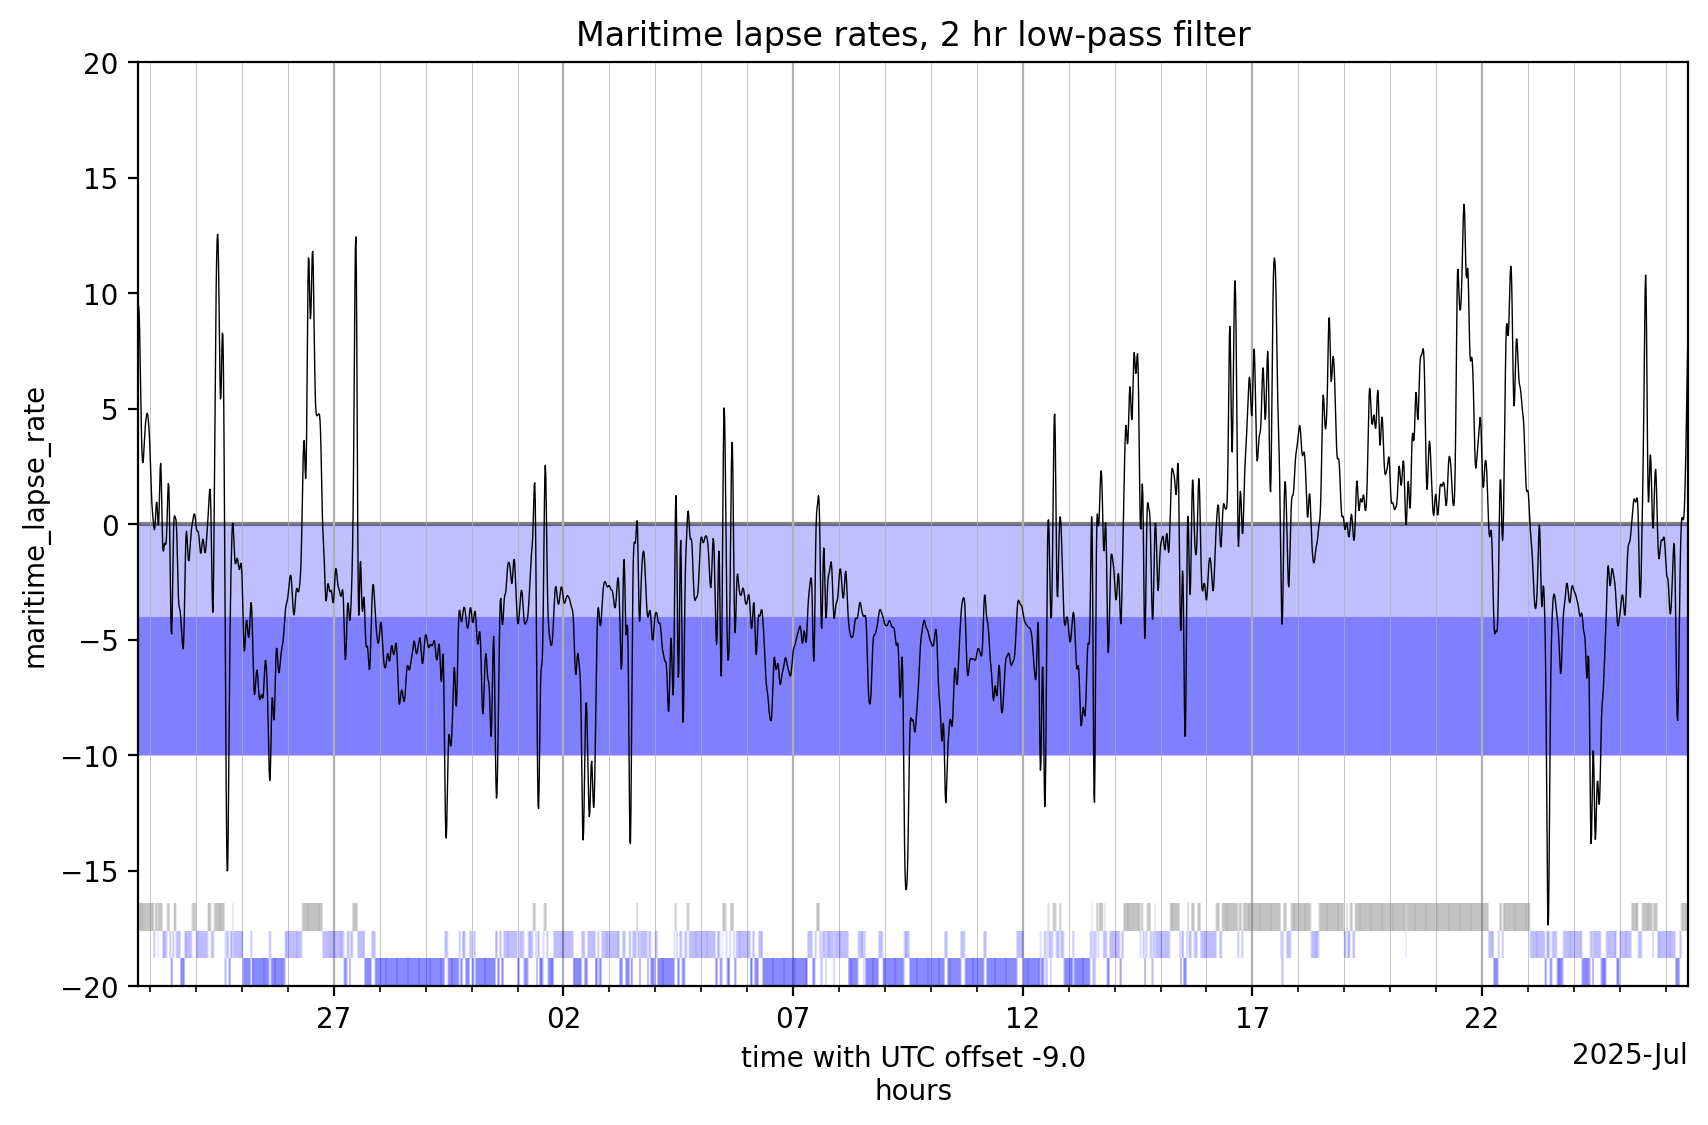

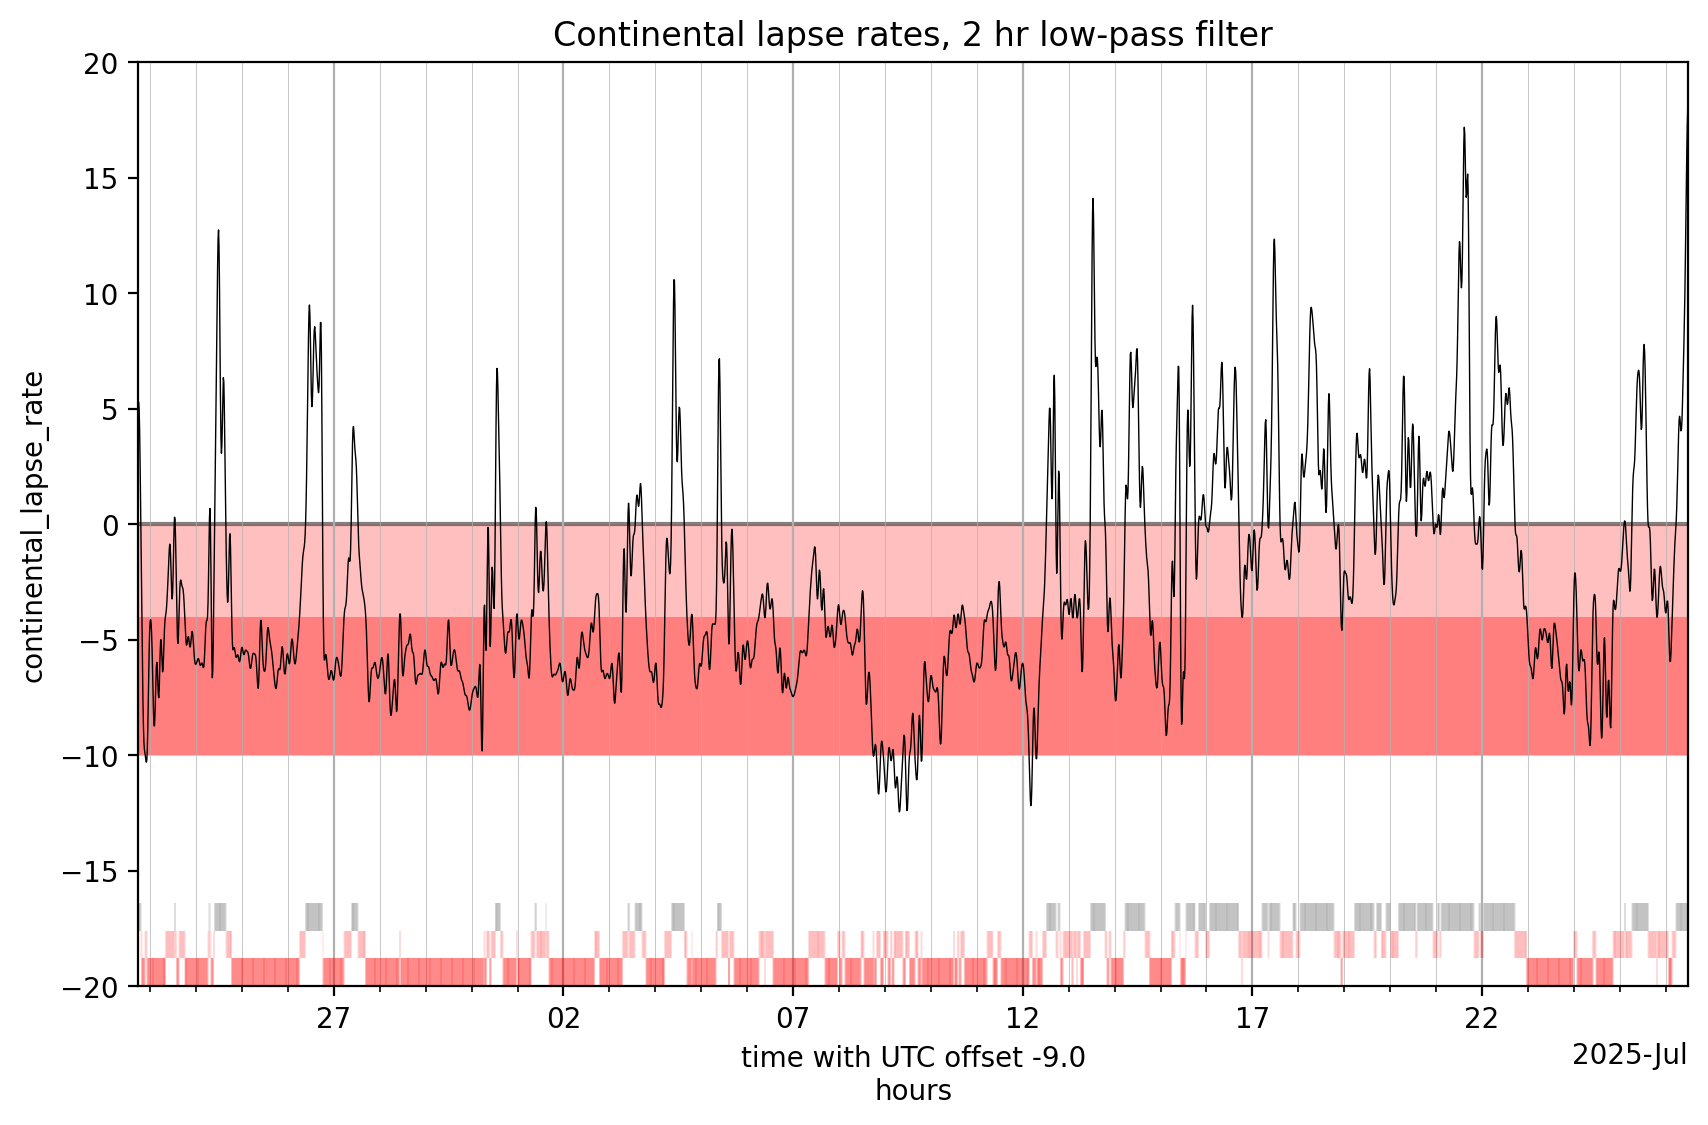

In [7]:
# Configure Butterworth filter for plotting
# For 5-minute data: fs = 1/300 Hz (sampling frequency)
# upper = 1/6 means cutoff at 6 samples = 30 minutes

FILTER_ORDER = 4
FILTER_LOWER = None  # Low-pass filter only
# FILTER_FS = 1 / 300  # Sampling frequency for 5-minute data (1 sample per 300 seconds)
FILTER_UPPER = 1 / (2 * 60 * 60)  # 2 hr cutoff

# For 15-min data: fs = 1/(300 * 3) Hz
FILTER_FS = 1 / (300 * 3)

for is_maritime, da_plot in zip(
    [True, False], [ds["maritime_lapse_rate"], ds["continental_lapse_rate"]]
):
    if is_maritime:
        title = "Maritime lapse rates, 2 hr low-pass filter"
        color = "blue"
    else:
        title = "Continental lapse rates, 2 hr low-pass filter"
        color = "red"

    fig, ax = plt.subplots(dpi=200, figsize=(10, 6))
    ax.set_ylim(-20, 20)
    ax.set_xlim(ds.datetime[0], ds.datetime[-1])

    da_plot.values = butterworth_filter(
        da_plot.values,
        fs=FILTER_FS,
        order=FILTER_ORDER,
        lower=FILTER_LOWER,
        upper=FILTER_UPPER,
    )
    da_plot.plot(ax=ax, lw=0.5, c="black")

    stable_periods = da_plot < 0
    expected_lapse_rate_periods = (da_plot < -4) & (da_plot > -10)
    # ax.fill_between(ds.datetime, -1e10, 1e10, where=stable_periods, color='green', alpha=0.3, lw=0)
    # ax.fill_between(ds.datetime, -1e10, 1e10, where=~stable_periods, color='red', alpha=0.3, lw=0)
    ax.fill_between(ds.datetime, -4, 0, color=color, alpha=0.25, lw=0)
    ax.fill_between(ds.datetime, -10, -4, color=color, alpha=0.5, lw=0)

    ymin, ymax = ax.get_ylim()

    length = (ymax - ymin) * 0.03  # 2% of axis height
    offset = ymin + length / 2  # pin to bottom of plot

    ax.eventplot(
        ds.datetime[stable_periods & ~expected_lapse_rate_periods],
        lineoffsets=offset + length,
        linelengths=length,
        lw=0.1,
        alpha=0.5,
        colors=color,
    )
    ax.eventplot(
        ds.datetime[expected_lapse_rate_periods],
        lineoffsets=offset,
        linelengths=length,
        lw=0.1,
        alpha=1,
        colors=color,
    )
    ax.eventplot(
        ds.datetime[~stable_periods],
        lineoffsets=offset + 2 * length,
        linelengths=length,
        lw=0.1,
        alpha=1,
        colors="grey",
    )

    ax.axhline(0, c="grey", zorder=0, lw=1.5)
    ax.grid(which="both", axis="x")
    ax.xaxis.set_major_locator(mpl.dates.DayLocator(interval=5))
    ax.xaxis.set_minor_locator(mpl.dates.DayLocator(interval=1))
    ax.grid(which="minor", lw=0.25)
    ax.set_title(title)


# Version for JIRP Workshop

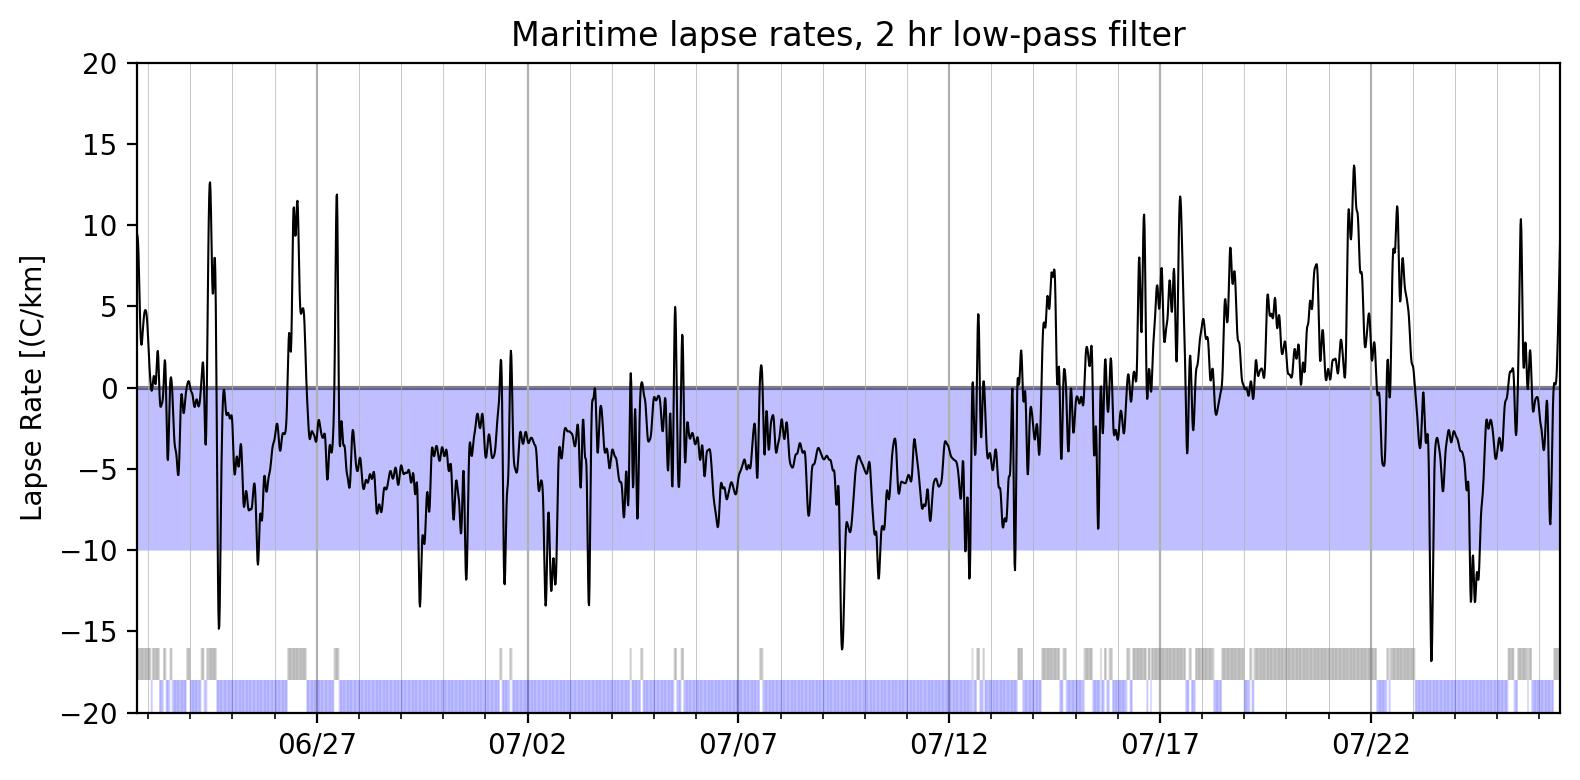

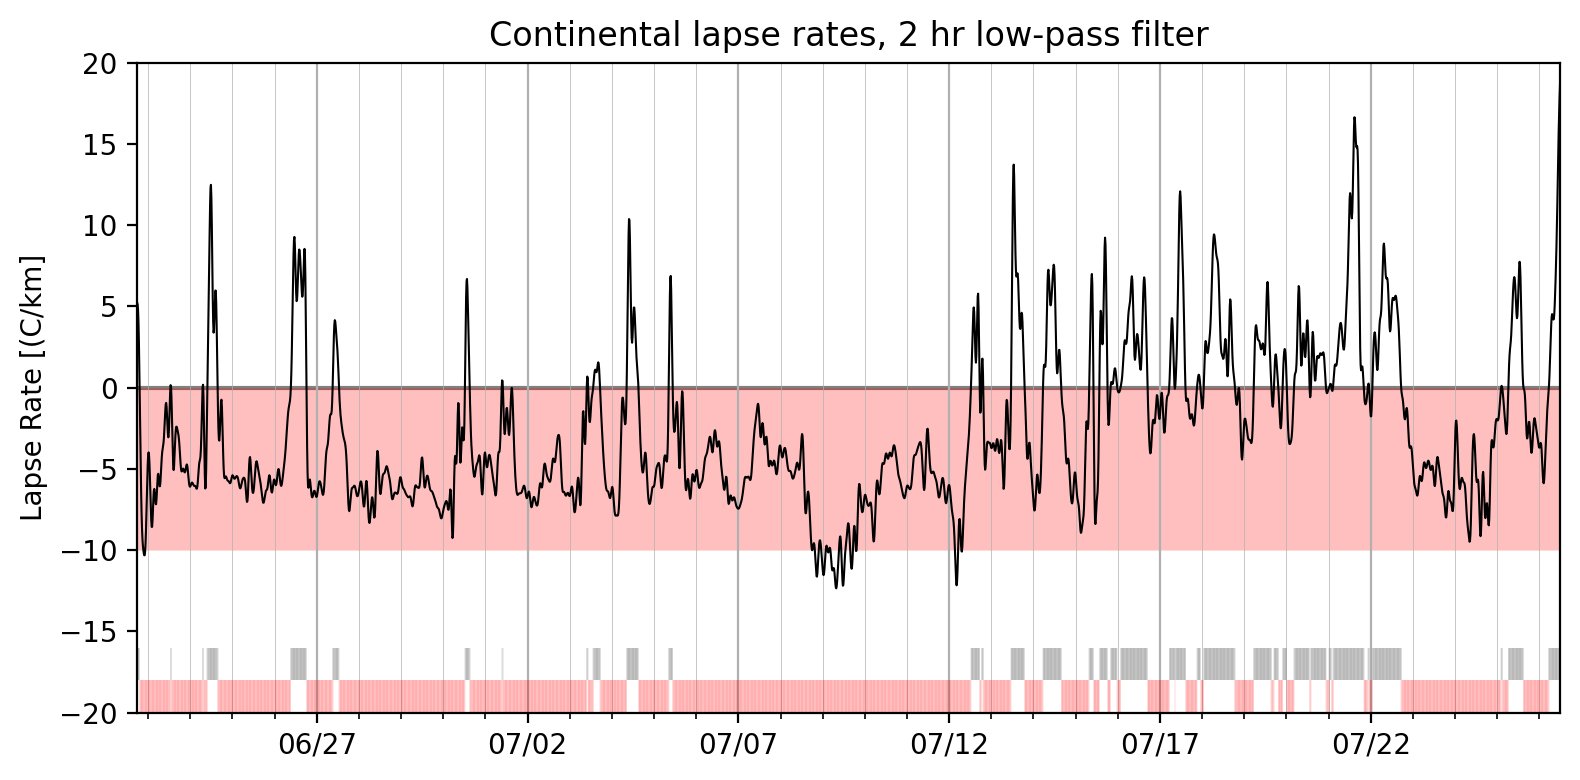

In [8]:
# Configure Butterworth filter for plotting
# For 5-minute data: fs = 1/300 Hz (sampling frequency)
# upper = 1/6 means cutoff at 6 samples = 30 minutes

FILTER_ORDER = 4
FILTER_LOWER = None  # Low-pass filter only
# FILTER_FS = 1 / 300  # Sampling frequency for 5-minute data (1 sample per 300 seconds)
FILTER_UPPER = 1 / (2 * 60 * 60)  # 2 hr cutoff

# For 15-min data: fs = 1/(300 * 3) Hz
FILTER_FS = 1 / (300 * 3)

for is_maritime, da_plot in zip(
    [True, False], [ds["maritime_lapse_rate"], ds["continental_lapse_rate"]]
):
    if is_maritime:
        title = "Maritime lapse rates, 2 hr low-pass filter"
        color = "blue"
    else:
        title = "Continental lapse rates, 2 hr low-pass filter"
        color = "red"

    fig, ax = plt.subplots(dpi=200, figsize=(8, 4))
    ax.set_ylim(-20, 20)
    ax.set_xlim(ds.datetime[0], ds.datetime[-1])

    da_plot.values = butterworth_filter(
        da_plot.values,
        fs=FILTER_FS,
        order=FILTER_ORDER,
        lower=FILTER_LOWER,
        upper=FILTER_UPPER,
    )
    da_plot.plot(ax=ax, lw=0.75, c="black")

    stable_periods = da_plot < 0
    expected_lapse_rate_periods = (da_plot < -4) & (da_plot > -10)
    # ax.fill_between(ds.datetime, -1e10, 1e10, where=stable_periods, color='green', alpha=0.3, lw=0)
    # ax.fill_between(ds.datetime, -1e10, 1e10, where=~stable_periods, color='red', alpha=0.3, lw=0)
    ax.fill_between(ds.datetime, -10, 0, color=color, alpha=0.25, lw=0)
    #ax.fill_between(ds.datetime, -10, -4, color=color, alpha=0.5, lw=0)

    ymin, ymax = ax.get_ylim()

    length = (ymax - ymin) * 0.05  # 2% of axis height
    offset = ymin + length / 2  # pin to bottom of plot

    ax.eventplot(
        ds.datetime[stable_periods | expected_lapse_rate_periods],
        lineoffsets=offset,
        linelengths=length,
        lw=0.1,
        alpha=0.5,
        colors=color,
    )
    ax.eventplot(
        ds.datetime[~stable_periods],
        lineoffsets=offset + 1 * length,
        linelengths=length,
        lw=0.1,
        alpha=1,
        colors="grey",
    )

    ax.axhline(0, c="grey", zorder=0, lw=1.5)
    ax.grid(which="both", axis="x")
    ax.xaxis.set_major_locator(mpl.dates.DayLocator(interval=5))
    ax.xaxis.set_minor_locator(mpl.dates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mpl.dates.DateFormatter('%m/%d'))
    ax.grid(which="minor", lw=0.25)
    ax.set_ylabel("Lapse Rate [(C/km]")
    ax.set_xlabel("")
    ax.set_title(title)
    fig.tight_layout()


# Show continental site data

NameError: name 'full_period_start' is not defined

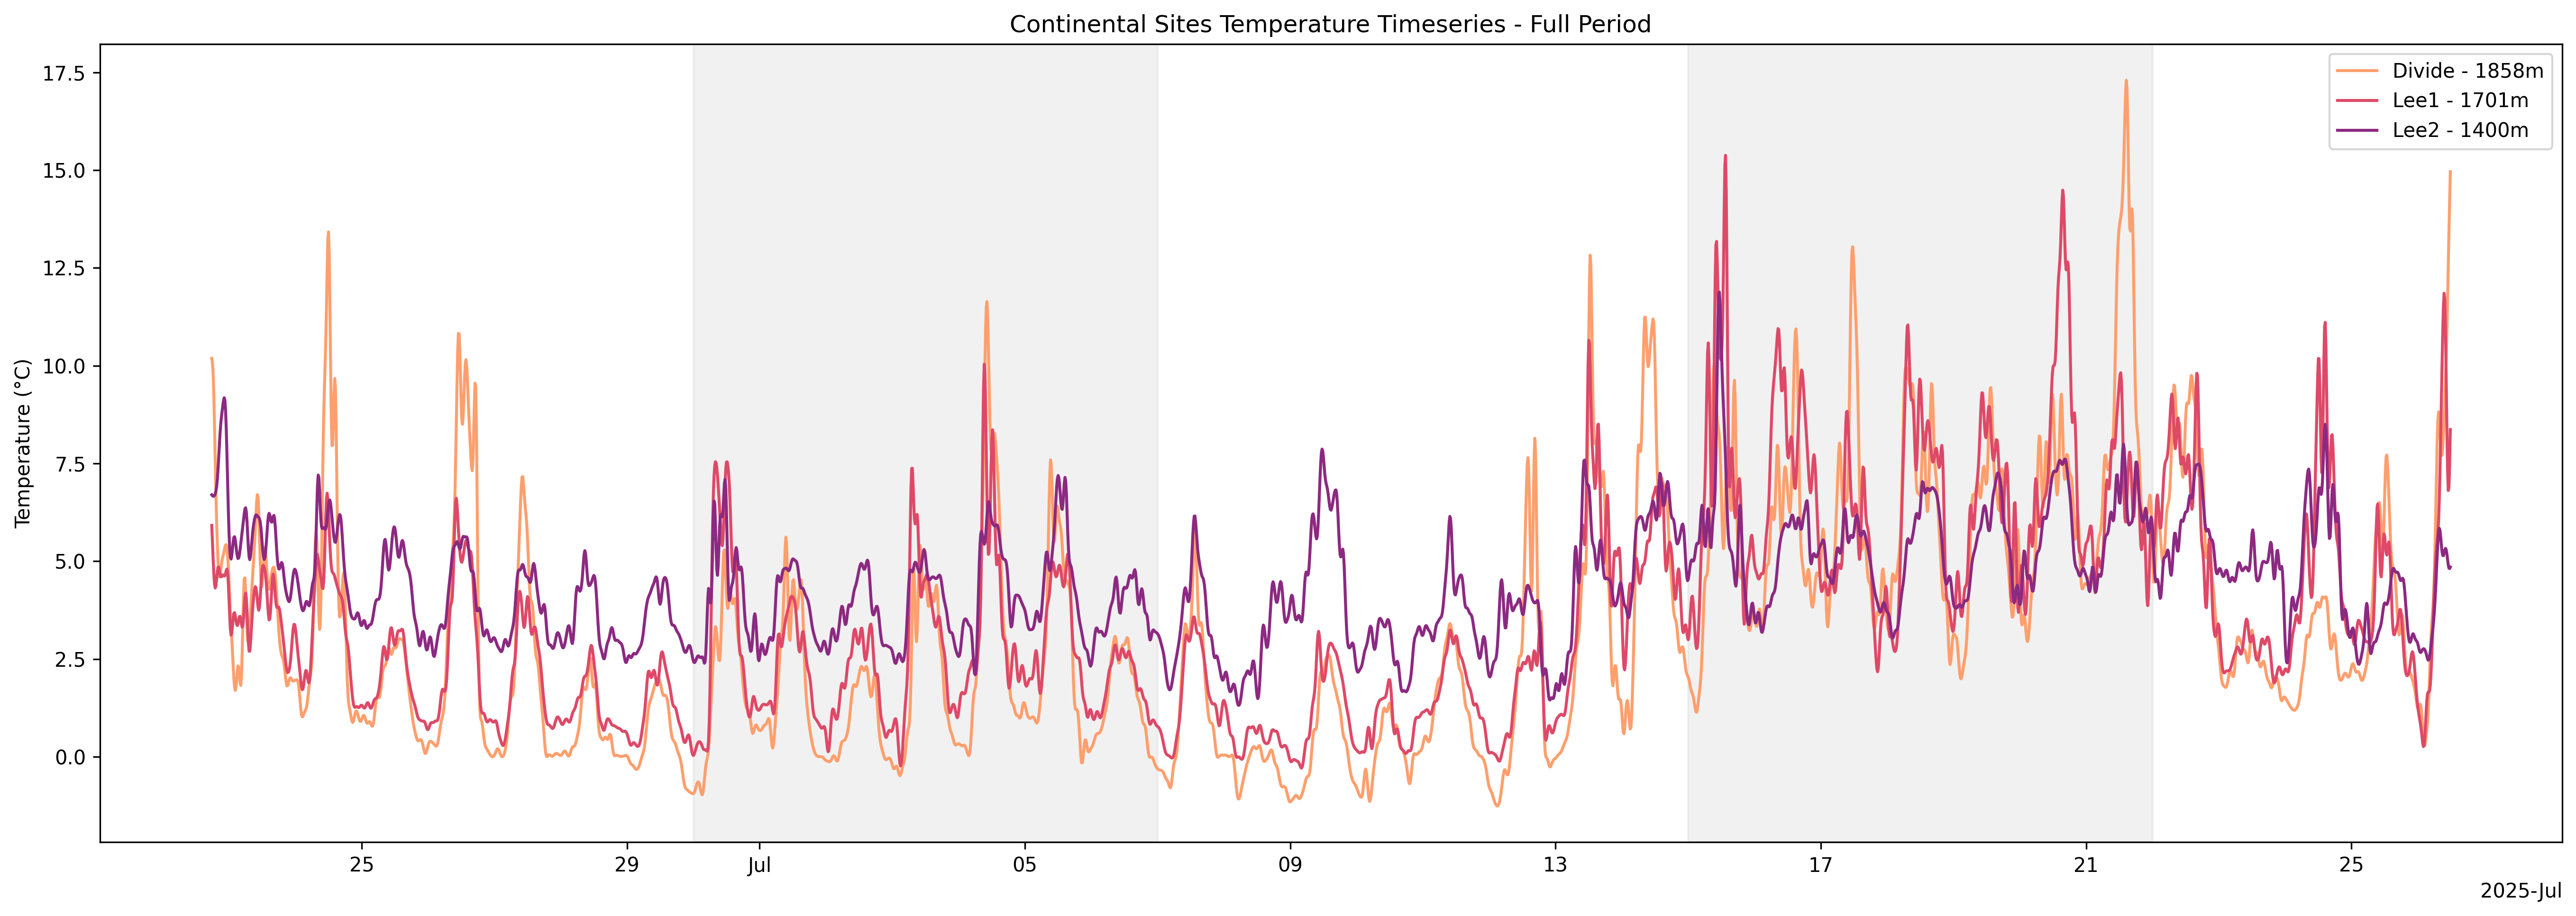

In [11]:
selected_continental_sites = [
    "Divide",
    "Lee1",
    "Lee2",
]  # Sites to include in plots (plotting order)
continental_row_order = [
    0,
    1,
    2,
]  # Can change order: 0=full period, 1=zoom periods, 2=lapse rates

MARITIME_COLORS = [plt.cm.viridis(0.8), plt.cm.viridis(0.5), plt.cm.viridis(0.2)]
CONTINENTAL_COLORS = [plt.cm.magma(0.8), plt.cm.magma(0.6), plt.cm.magma(0.4)]
row_configs = {
    0: {"title": "Full Period", "setup": "full_period"},
    1: {"title": "Lapse Rates", "setup": "lapse_rates"},
    2: {"title": "Zoom Periods", "setup": "zoom_periods"},
}

stab_start = pd.Timestamp("2025/06/30")
stab_end = pd.Timestamp("2025/07/07")
inv_start = pd.Timestamp("2025/07/15")
inv_end = pd.Timestamp("2025/07/22")

# Plot layout (matching Figure 1)
fig = plt.figure(figsize=(18, 12), dpi=300, layout="constrained")
gs = gridspec.GridSpec(3, 2, height_ratios=[2, 1, 1], hspace=0.05, wspace=0, figure=fig)

# Get temperature data for selected continental sites
n_cont_sites = len(selected_continental_sites)
# Use continental colors from the configured color scheme
cont_colors = [CONTINENTAL_COLORS[i % len(CONTINENTAL_COLORS)] for i in range(n_cont_sites)]

continental_sites_data = {}
continental_site_elevations = {}
for i, site in enumerate(selected_continental_sites):
    site_data = ds.where(ds.site_id == site, drop=True)
    if len(site_data.sensor_idx) > 0:
        continental_sites_data[site] = site_data.temp_c.mean("sensor_idx")
        continental_site_elevations[site] = float(site_data.elevation.mean().values)

# Row arrangement based on continental_row_order
for row_idx, config_idx in enumerate(continental_row_order):
    config = row_configs[config_idx]

    if config["setup"] == "full_period":
        # Full period timeseries (spans both columns)
        ax = fig.add_subplot(gs[row_idx, :])

        # Add shaded regions for zoom periods
        ax.axvspan(stab_start, stab_end, alpha=0.3, color="lightgrey", zorder=2)
        ax.axvspan(inv_start, inv_end, alpha=0.3, color="lightgrey", zorder=2)

        for i, (site, temp_data) in enumerate(continental_sites_data.items()):
            elev = continental_site_elevations[site]
            # Apply Butterworth filter to temperature data
            temp_filtered = butterworth_filter(
                temp_data.values,
                fs=FILTER_FS,
                order=FILTER_ORDER,
                lower=FILTER_LOWER,
                upper=FILTER_UPPER,
            )
            temp_data_filtered = xr.DataArray(
                temp_filtered, coords=temp_data.coords, dims=temp_data.dims
            )
            temp_data_filtered.plot(
                ax=ax, color=cont_colors[i], label=f"{site} - {elev:.0f}m", zorder=3
            )

        ax.set_title("Continental Sites Temperature Timeseries - Full Period")
        ax.set_ylabel("Temperature (°C)")
        ax.set_xlabel("")
        ax.legend()
        ax.set_xlim(full_period_start, full_period_end)
        ax.grid(True, alpha=0.3, which="major")
        ax.grid(True, alpha=0.1, which="minor")
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Set x-axis locators and formatting (like Figure 4)
        ax.xaxis.set_major_locator(DayLocator())
        ax.xaxis.set_minor_locator(HourLocator(interval=12))
        ax.xaxis.set_major_formatter(DateFormatter("%b %d"))

        # Get all the tick labels and set every other one to empty
        labels = ax.get_xticklabels()
        for i, label in enumerate(labels):
            if i % 2 == 1:  # Hide every other label (odd indices)
                label.set_visible(False)

        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

    elif config["setup"] == "zoom_periods":
        # Two side-by-side zoom periods
        ax_left = fig.add_subplot(gs[row_idx, 0])
        ax_right = fig.add_subplot(gs[row_idx, 1], sharey=ax_left)

        zoom_axes = [ax_left, ax_right]
        zoom_periods = [
            (june_end_slice, "Last 5 Days of June"),
            (july_mid_slice, "July 17-22"),
        ]

        for ax, (time_slice, title_suffix) in zip(zoom_axes, zoom_periods):
            for i, (site, temp_data) in enumerate(continental_sites_data.items()):
                elev = continental_site_elevations[site]
                temp_data.sel(datetime=time_slice).plot(
                    ax=ax, color=cont_colors[i], label=f"{site} - {elev:.0f}m", zorder=3
                )

            ax.set_title(f"Continental Sites Temperature - {title_suffix}")
            ax.set_ylabel("Temperature (°C)")
            ax.set_xlabel("Time")
            ax.grid(True, alpha=0.3, which="major")
            ax.grid(True, alpha=0.1, which="minor")
            ax.set_axisbelow(True)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            # Set axis locators and formatting (like Figure 4)
            ax.yaxis.set_major_locator(MultipleLocator(5))
            ax.yaxis.set_minor_locator(MultipleLocator(1))
            ax.xaxis.set_major_locator(DayLocator())
            ax.xaxis.set_minor_locator(HourLocator(interval=12))
            ax.xaxis.set_major_formatter(DateFormatter("%b %d"))
            # Rotate labels
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

    elif config["setup"] == "lapse_rates":
        # Lapse rate timeseries (spans both columns)
        ax = fig.add_subplot(gs[row_idx, :])

        # Add grey zero line (only for lapse rate plots)
        ax.axhline(y=0, color="grey", linewidth=1.5, zorder=1)

        # Plot overall continental lapse rate with filtering
        continental_lapse = ds.continental_lapse_rate * 1000
        # Apply Butterworth filter to lapse rate data
        continental_lapse_filtered = butterworth_filter(
            continental_lapse.values,
            fs=FILTER_FS,
            order=FILTER_ORDER,
            lower=FILTER_LOWER,
            upper=FILTER_UPPER,
        )
        continental_lapse_filtered_da = xr.DataArray(
            continental_lapse_filtered,
            coords=continental_lapse.coords,
            dims=continental_lapse.dims,
        )
        continental_lapse_filtered_da.plot(
            ax=ax,
            color="black",
            label="All continental sites regression",
            linewidth=2,
            alpha=0.8,
            zorder=3,
        )
        ax.fill_between(
            ds.datetime,
            0,
            continental_lapse_filtered_da,
            where=(continental_lapse_filtered_da > 0),
            color="lightgrey",
            label="Inverted",
            zorder=0.1,
        )

        ylims = (-20, 20)
        ax.set_ylim(ylims)
        ax.set_ylabel("Lapse Rate (°C/km)")
        ax.set_xlabel("Time")
        ax.legend(loc="upper right")
        #ax.set_xlim(full_period_start, full_period_end)
        ax.grid(True, alpha=0.3, which="major")
        ax.grid(True, alpha=0.1, which="minor")
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Set axis locators and formatting (like Figure 4)
        ax.yaxis.set_major_locator(MultipleLocator(5))
        ax.yaxis.set_minor_locator(MultipleLocator(1))
        ax.xaxis.set_major_locator(DayLocator())
        ax.xaxis.set_minor_locator(HourLocator(interval=12))
        ax.xaxis.set_major_formatter(DateFormatter("%b %d"))
        # Hide every other label for cleaner appearance
        for i, label in enumerate(ax.xaxis.get_majorticklabels()):
            if i % 2 == 1:
                label.set_visible(False)

In [12]:
rows = []
for site_type in ["maritime", "continental"]:
    lr = ds[f"{site_type}_lapse_rate"]

    stable = lr < 0
    inverted_mean = float(lr.sel(datetime=~stable).mean())
    stable_mean = float(lr.sel(datetime=stable).mean())
    n_days_stable = int(stable.sum()) * 15 / 60 / 24
    pct_stable = float(stable.sum() / len(lr.datetime) * 100)
    mean_lr = float(lr.mean())

    rows.append(
        {
            "site type": site_type,
            "mean lapse rate": mean_lr,
            "inverted mean lapse rate": inverted_mean,
            "stable mean lapse rate": stable_mean,
            "n days stable": n_days_stable,
            "pct stable": pct_stable,
        }
    )

df_lr = pd.DataFrame(rows).set_index("site type")
#df_lr.to_csv("lapse_rate_stats.csv", float_format="%.2f")
print(df_lr)

             mean lapse rate  inverted mean lapse rate  \
site type                                                
maritime           -2.175717                  3.642653   
continental        -2.761358                  4.074097   

             stable mean lapse rate  n days stable  pct stable  
site type                                                       
maritime                  -4.471519      24.208333   71.706263  
continental               -5.016469      25.385417   75.192842  


Text(0.5, 0, 'Date')

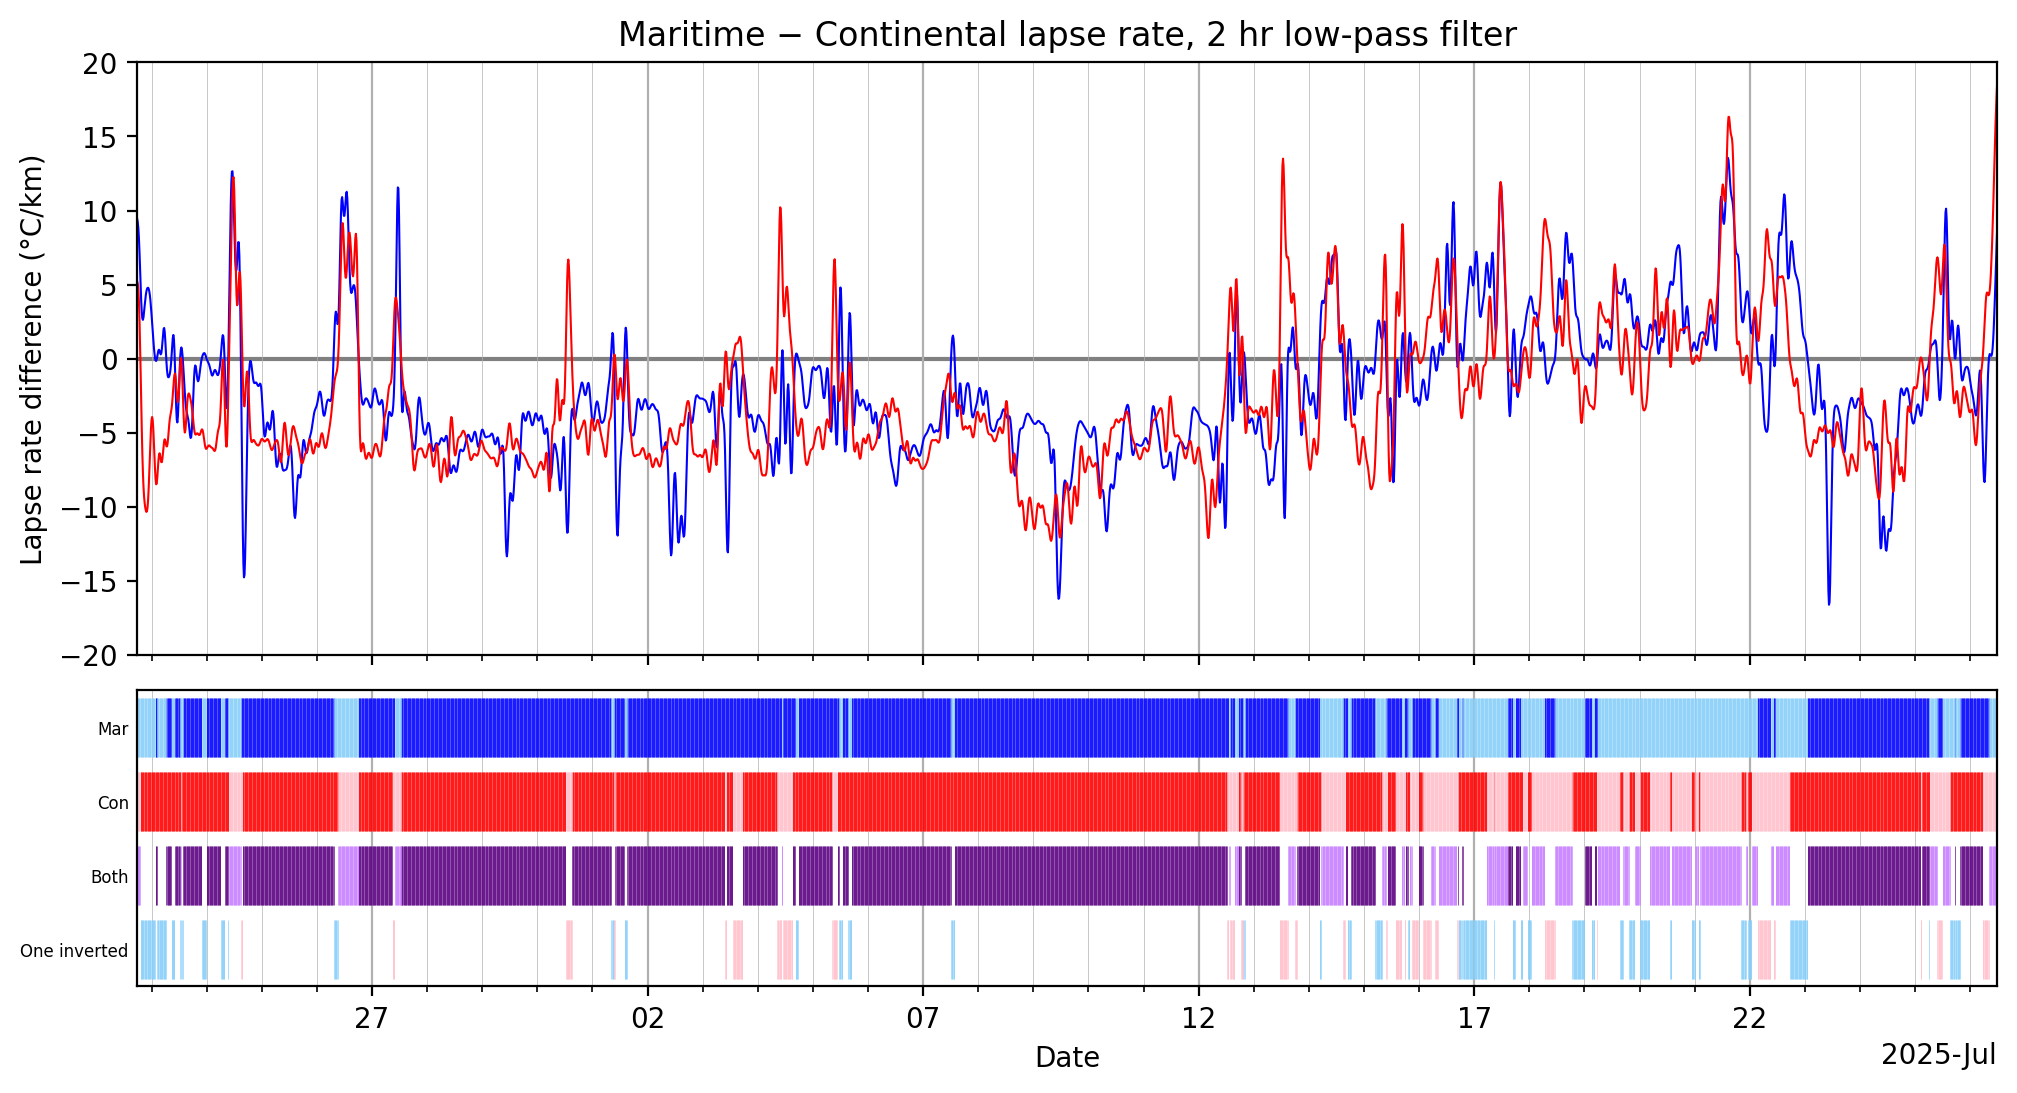

In [13]:
# Configure Butterworth filter for plotting
FILTER_ORDER = 4
FILTER_LOWER = None  # Low-pass filter only
FILTER_UPPER = 1 / (2 * 60 * 60)  # 2 hr cutoff
FILTER_FS = 1 / (300 * 3)  # For 15-min data

# --- Filter both lapse rate series ---
maritime_lr = ds["maritime_lapse_rate"].copy()
continental_lr = ds["continental_lapse_rate"].copy()

maritime_lr.values = butterworth_filter(
    maritime_lr.values,
    fs=FILTER_FS,
    order=FILTER_ORDER,
    lower=FILTER_LOWER,
    upper=FILTER_UPPER,
)
continental_lr.values = butterworth_filter(
    continental_lr.values,
    fs=FILTER_FS,
    order=FILTER_ORDER,
    lower=FILTER_LOWER,
    upper=FILTER_UPPER,
)

# Compute difference: maritime - continental
diff_lr = maritime_lr - continental_lr

# --- Build figure with 2 subplots ---
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    dpi=200,
    figsize=(12, 6),
    gridspec_kw={"height_ratios": [2, 1]},
    sharex=True,
)
fig.subplots_adjust(hspace=0.08)

# ---- Top subplot: timeseries ----
ax1.set_ylim(-20, 20)
ax1.set_xlim(ds.datetime[0], ds.datetime[-1])

maritime_lr.plot(ax=ax1, lw=0.75, c="blue")
continental_lr.plot(ax=ax1, lw=0.75, c="red")

# Compute boolean masks
diff_pos = diff_lr > 0
diff_neg = diff_lr < 0

mar_pos = maritime_lr > 0
mar_neg = maritime_lr < 0

con_pos = continental_lr > 0
con_neg = continental_lr < 0

both_pos = mar_pos & con_pos
both_neg = mar_neg & con_neg

ax1.axhline(0, c="grey", zorder=0, lw=1.5)
ax1.grid(which="both", axis="x")
ax1.xaxis.set_major_locator(mpl.dates.DayLocator(interval=5))
ax1.xaxis.set_minor_locator(mpl.dates.DayLocator(interval=1))
ax1.grid(which="minor", lw=0.25)
ax1.set_title("Maritime − Continental lapse rate, 2 hr low-pass filter")
ax1.set_ylabel("Lapse rate difference (°C/km)")
ax1.set_xlabel("")

# ---- Bottom subplot: all paired rows ----
ax2.set_xlim(ds.datetime[0], ds.datetime[-1])

mar_inv_only = mar_pos & ~con_pos
con_inv_only = con_pos & ~mar_pos

length = 0.8

all_pairs = [
    ("One inverted", mar_inv_only, "lightskyblue", con_inv_only, "pink"),
    ("Both", both_neg, "#5B0082", both_pos, "#C77DFF"),
    ("Con", con_neg, "red", con_pos, "pink"),
    ("Mar", mar_neg, "blue", mar_pos, "lightskyblue"),
]

offsets = [i + 0.5 for i in range(len(all_pairs))]

for i, (label, mask_a, color_a, mask_b, color_b) in enumerate(all_pairs):
    ax2.eventplot(
        ds.datetime[mask_a.values],
        lineoffsets=offsets[i],
        linelengths=length,
        lw=0.3,
        alpha=0.8,
        colors=color_a,
    )
    ax2.eventplot(
        ds.datetime[mask_b.values],
        lineoffsets=offsets[i],
        linelengths=length,
        lw=0.3,
        alpha=0.8,
        colors=color_b,
    )

row_labels = [label for label, *_ in all_pairs]
ax2.set_ylim(0, len(all_pairs))
ax2.set_yticks(offsets)
ax2.set_yticklabels(row_labels, fontsize=6)
ax2.tick_params(axis="y", length=0, pad=3)

ax2.grid(which="both", axis="x")
ax2.xaxis.set_major_locator(mpl.dates.DayLocator(interval=5))
ax2.xaxis.set_minor_locator(mpl.dates.DayLocator(interval=1))
ax2.grid(which="minor", lw=0.25)
ax2.set_xlabel("Date")

# plt.savefig("/mnt/user-data/outputs/lapse_rate_difference.png", bbox_inches="tight")

In [14]:
mar_temp = select_sensors(ds["temp_c"], site_id="Windward1")
con_temp = select_sensors(ds["temp_c"], site_id="Lee1")

mar_pdd = np.maximum(mar_temp.values, 0).cumsum() / 96
con_pdd = np.maximum(con_temp.values, 0).cumsum() / 96

mar_pdd

array([8.23765432e-02, 1.62102623e-01, 2.34378858e-01, ...,
       1.14180208e+02, 1.14283769e+02, 1.14384861e+02], shape=(3241,))

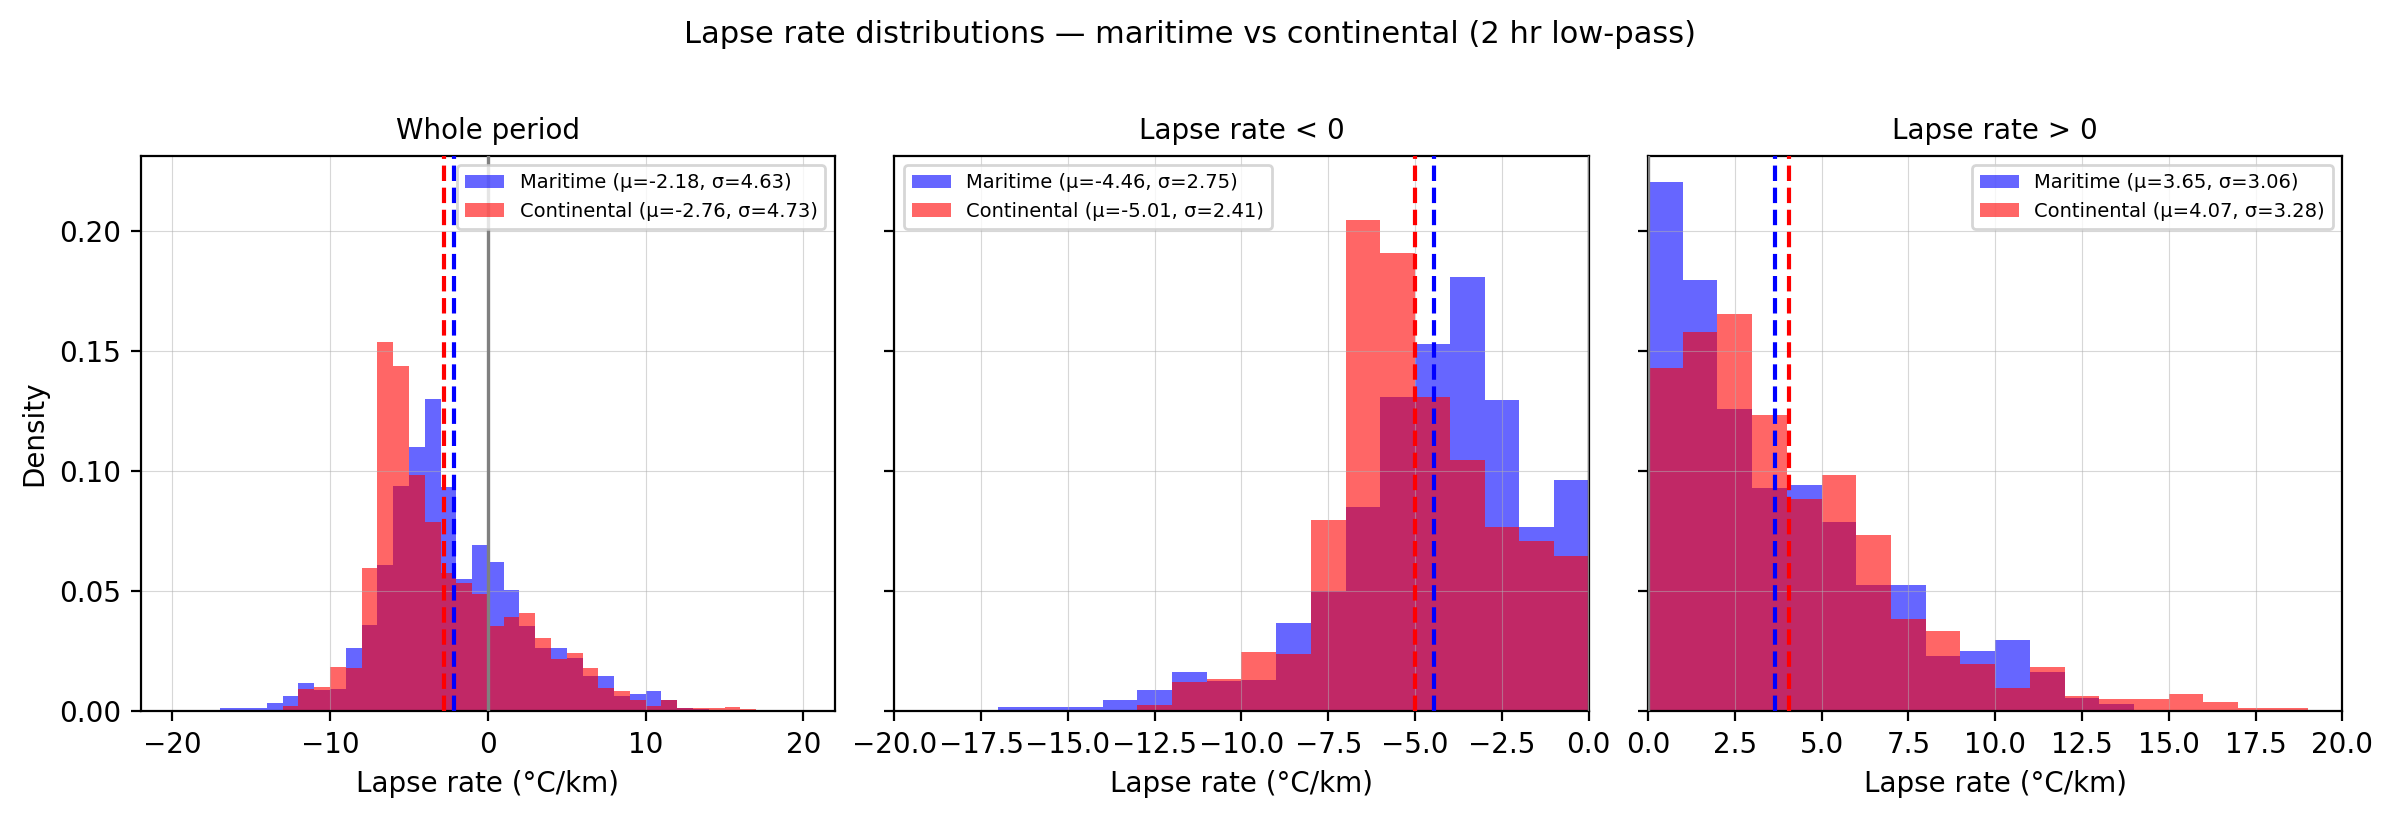

In [15]:
fig, axes = plt.subplots(
    1, 3,
    dpi=200,
    figsize=(12, 4),
    sharey=True,
)
fig.subplots_adjust(wspace=0.08)

HIST_BINS = np.arange(-20, 21, 1)
HIST_KWARGS = dict(bins=HIST_BINS, density=True, alpha=0.6, edgecolor="none")

mar = maritime_lr.values
con = continental_lr.values

# Each series gets its own mask independently
conditions = [
    ("Whole period",  mar,                      con),
    ("Lapse rate < 0", mar[mar < 0],            con[con < 0]),
    ("Lapse rate > 0", mar[mar > 0],            con[con > 0]),
]

for ax, (title, mar_vals, con_vals) in zip(axes, conditions):

    def legend_label(name, vals):
        n    = np.sum(~np.isnan(vals))
        mu   = np.nanmean(vals)
        sig  = np.nanstd(vals)
        return f"{name} (μ={mu:.2f}, σ={sig:.2f})"

    ax.hist(mar_vals, **HIST_KWARGS, color="blue", label=legend_label("Maritime",     mar_vals))
    ax.hist(con_vals, **HIST_KWARGS, color="red",  label=legend_label("Continental",  con_vals))

    ax.axvline(0, color="grey", lw=1.2, zorder=3)
    ax.axvline(np.nanmean(mar_vals), color="blue", lw=1.5, ls="--", zorder=4)
    ax.axvline(np.nanmean(con_vals), color="red",  lw=1.5, ls="--", zorder=4)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Lapse rate (°C/km)")
    #ax.set_xlim(-20, 20)
    ax.grid(axis="y", lw=0.4, alpha=0.5)
    ax.grid(axis="x", lw=0.4, alpha=0.5)
    ax.legend(fontsize=7)

axes[0].set_ylabel("Density")
axes[1].set_xlim(-20,0)
axes[2].set_xlim(0, 20)

fig.suptitle("Lapse rate distributions — maritime vs continental (2 hr low-pass)",
             fontsize=11, y=1.01)

plt.tight_layout()
plt.show()

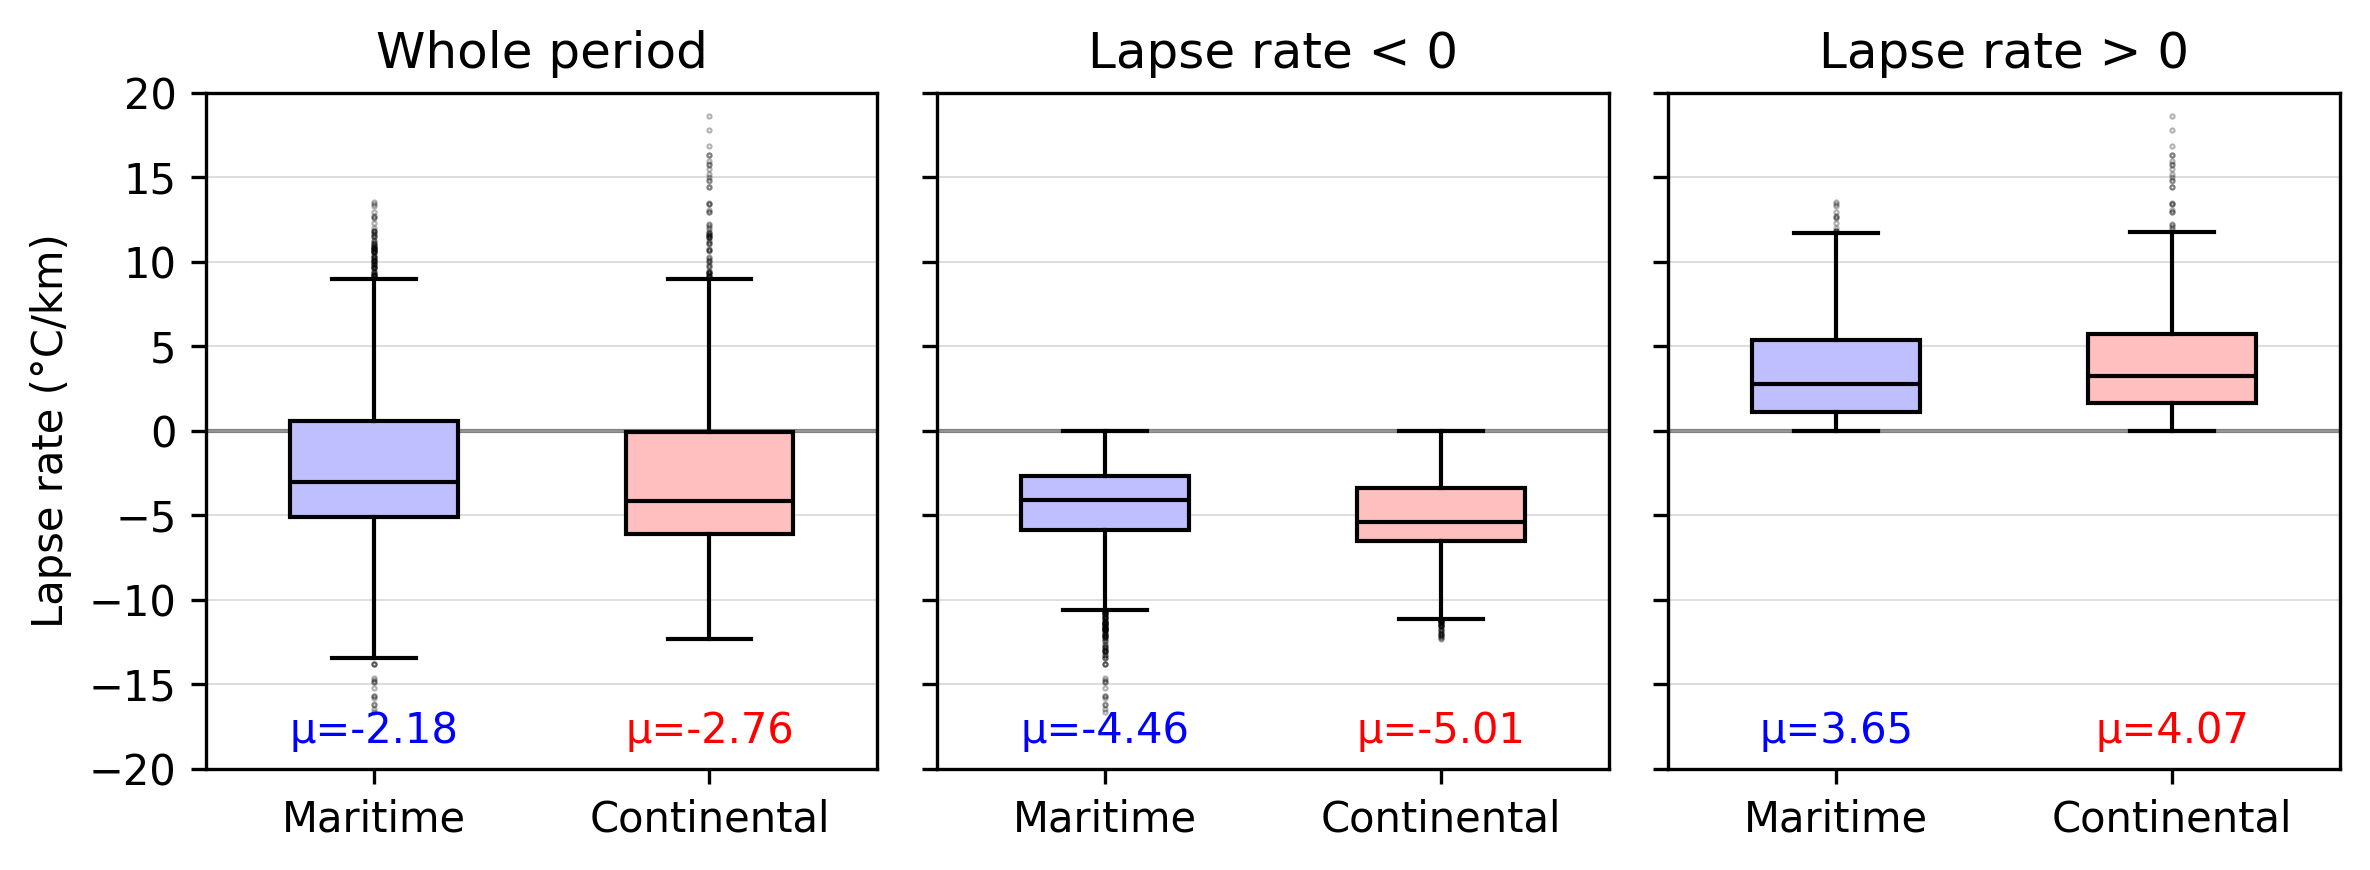

In [22]:
fig, axes = plt.subplots(
    1, 3,
    dpi=300,
    figsize=(8, 3),
    sharey=True,
)
fig.subplots_adjust(wspace=0.08)

mar = maritime_lr.values
con = continental_lr.values

conditions = [
    ("Whole period",   mar,           con),
    ("Lapse rate < 0", mar[mar < 0],  con[con < 0]),
    ("Lapse rate > 0", mar[mar > 0],  con[con > 0]),
]

series = [("Maritime", ["blue", "#BFBFFF"]), ("Continental", ["red","#FFBFBF"])]

for col, (cond_title, mar_vals, con_vals) in enumerate(conditions):
    ax = axes[col]

    for pos, (vals, (name, color)) in enumerate(zip([mar_vals, con_vals], series), start=1):
        clean = vals[~np.isnan(vals)]
        mu  = np.nanmean(clean)
        sig = np.nanstd(clean)
        n   = len(clean)

        ax.boxplot(
            clean,
            positions=[pos],
            vert=True,
            patch_artist=True,
            widths=0.5,
            showfliers=True,
            flierprops=dict(marker=".", markersize=1, alpha=0.3, color=color[0]),
            medianprops=dict(color="black", lw=1),
            boxprops=dict(facecolor=color[1]),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
        )

        ax.text(pos, -19,
                f"μ={mu:.2f}",
                ha="center", va="bottom", fontsize=10, color=color[0])

    ax.axhline(0, color="grey", lw=1, zorder=0)
    ax.set_xticks([1, 2])
    ax.set_xticklabels([name for name, _ in series])
    ax.set_title(cond_title)
    ax.set_ylim(-20, 20)
    ax.grid(axis="y", lw=0.4, alpha=0.5)
    if col == 0:
        ax.set_ylabel("Lapse rate (°C/km)")

plt.tight_layout()
plt.show()

Text(0.5, 0, 'Date')

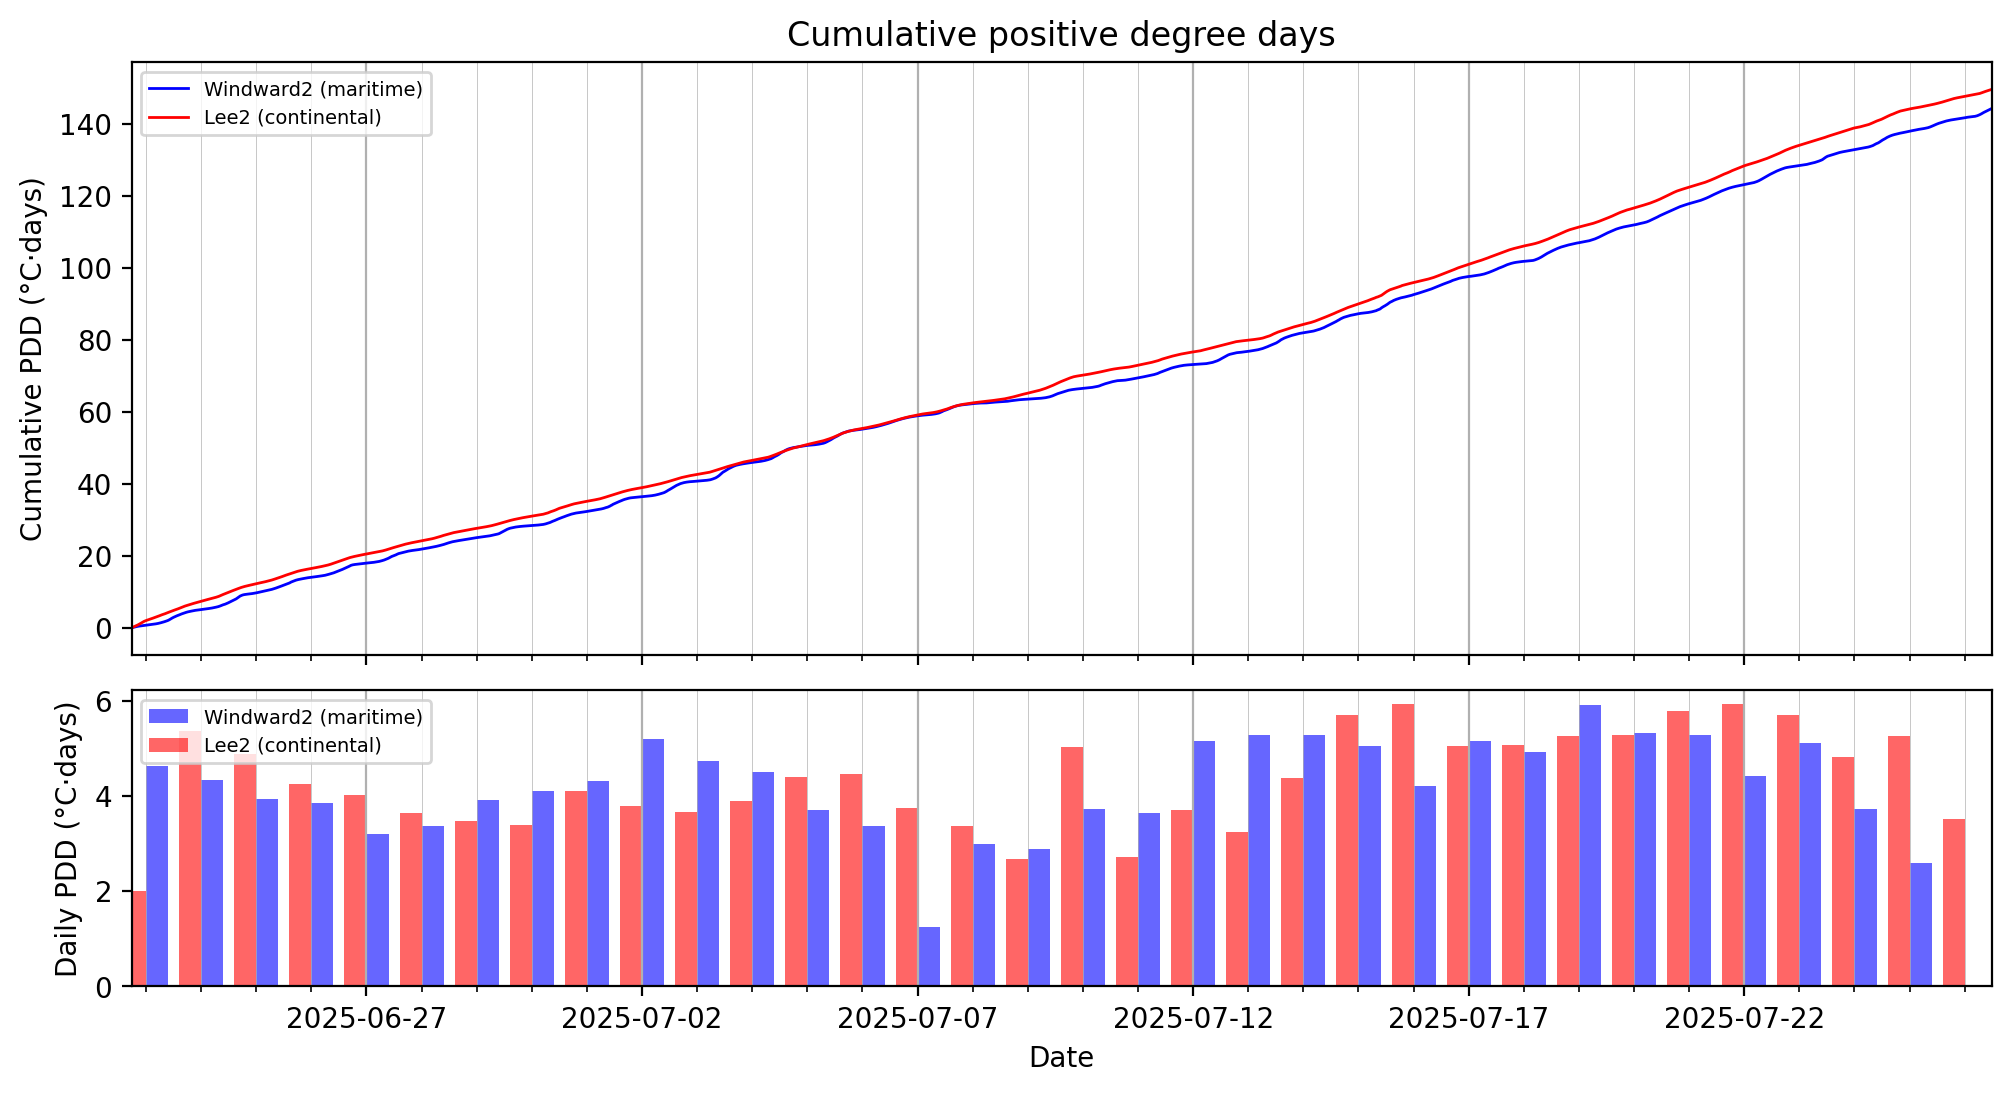

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configure Butterworth filter for plotting (lapse rate only)
FILTER_ORDER = 4
FILTER_LOWER = None  # Low-pass filter only
FILTER_UPPER = 1 / (2 * 60 * 60)  # 2 hr cutoff
FILTER_FS = 1 / (300 * 3)  # For 15-min data

# --- Cumulative positive degree days from raw temp ---
mar_temp = select_sensors(ds["temp_c"], site_id="Windward2")
con_temp = select_sensors(ds["temp_c"], site_id="Lee2")

# Clamp negatives to 0, scale to days (96 x 15-min intervals per day)
mar_pdd_vals = np.maximum(mar_temp.values, 0) / 96
con_pdd_vals = np.maximum(con_temp.values, 0) / 96

# --- Save PDD timeseries as data variables in the xarray dataset ---
import xarray as xr

ds["mar_pdd"] = xr.DataArray(
    mar_pdd_vals,
    coords=mar_temp.coords,
    dims=mar_temp.dims,
    attrs={"long_name": "Maritime instantaneous PDD", "units": "°C·days per timestep"},
)
ds["con_pdd"] = xr.DataArray(
    con_pdd_vals,
    coords=con_temp.coords,
    dims=con_temp.dims,
    attrs={"long_name": "Continental instantaneous PDD", "units": "°C·days per timestep"},
)

# --- Resample instantaneous PDD to daily sums for bar plot ---
times = pd.DatetimeIndex(ds.datetime.values)

mar_pdd_series = pd.Series(mar_pdd_vals.squeeze(), index=times)
con_pdd_series = pd.Series(con_pdd_vals.squeeze(), index=times)

mar_pdd_daily = mar_pdd_series.resample("1D").sum()
con_pdd_daily = con_pdd_series.resample("1D").sum()

# --- Build figure with 2 subplots ---
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    dpi=200,
    figsize=(12, 6),
    gridspec_kw={"height_ratios": [2, 1]},
    sharex=True,
)
fig.subplots_adjust(hspace=0.08)

# ---- Top subplot: cumulative positive degree days ----
ax1.set_xlim(ds.datetime[0], ds.datetime[-1])

ax1.plot(ds.datetime, mar_pdd_vals.cumsum(), lw=1, c="blue", label="Windward2 (maritime)")
ax1.plot(ds.datetime, con_pdd_vals.cumsum(), lw=1, c="red", label="Lee2 (continental)")

ax1.legend(fontsize=7, loc="upper left")
ax1.grid(which="both", axis="x")
ax1.xaxis.set_major_locator(mpl.dates.DayLocator(interval=5))
ax1.xaxis.set_minor_locator(mpl.dates.DayLocator(interval=1))
ax1.grid(which="minor", lw=0.25)
ax1.set_title("Cumulative positive degree days")
ax1.set_ylabel("Cumulative PDD (°C·days)")
ax1.set_xlabel("")

# ---- Bottom subplot: daily instantaneous PDD bar chart ----
ax2.set_xlim(ds.datetime[0], ds.datetime[-1])

bar_width = 0.4  # days
bar_offset = pd.Timedelta(hours=2*9.6)  # half of 0.4 days in hours, for centering offset

ax2.bar(
    mar_pdd_daily.index - bar_offset,
    mar_pdd_daily.values,
    width=bar_width,
    align="center",
    color="blue",
    alpha=0.6,
    label="Windward2 (maritime)",
)
ax2.bar(
    con_pdd_daily.index + bar_offset,
    con_pdd_daily.values,
    width=bar_width,
    align="center",
    color="red",
    alpha=0.6,
    label="Lee2 (continental)",
)

ax2.legend(fontsize=7, loc="upper left")
ax2.grid(which="both", axis="x")
ax2.xaxis.set_major_locator(mpl.dates.DayLocator(interval=5))
ax2.xaxis.set_minor_locator(mpl.dates.DayLocator(interval=1))
ax2.grid(which="minor", lw=0.25)
ax2.set_ylabel("Daily PDD (°C·days)")
ax2.set_xlabel("Date")

Text(0.5, 0, 'Date')

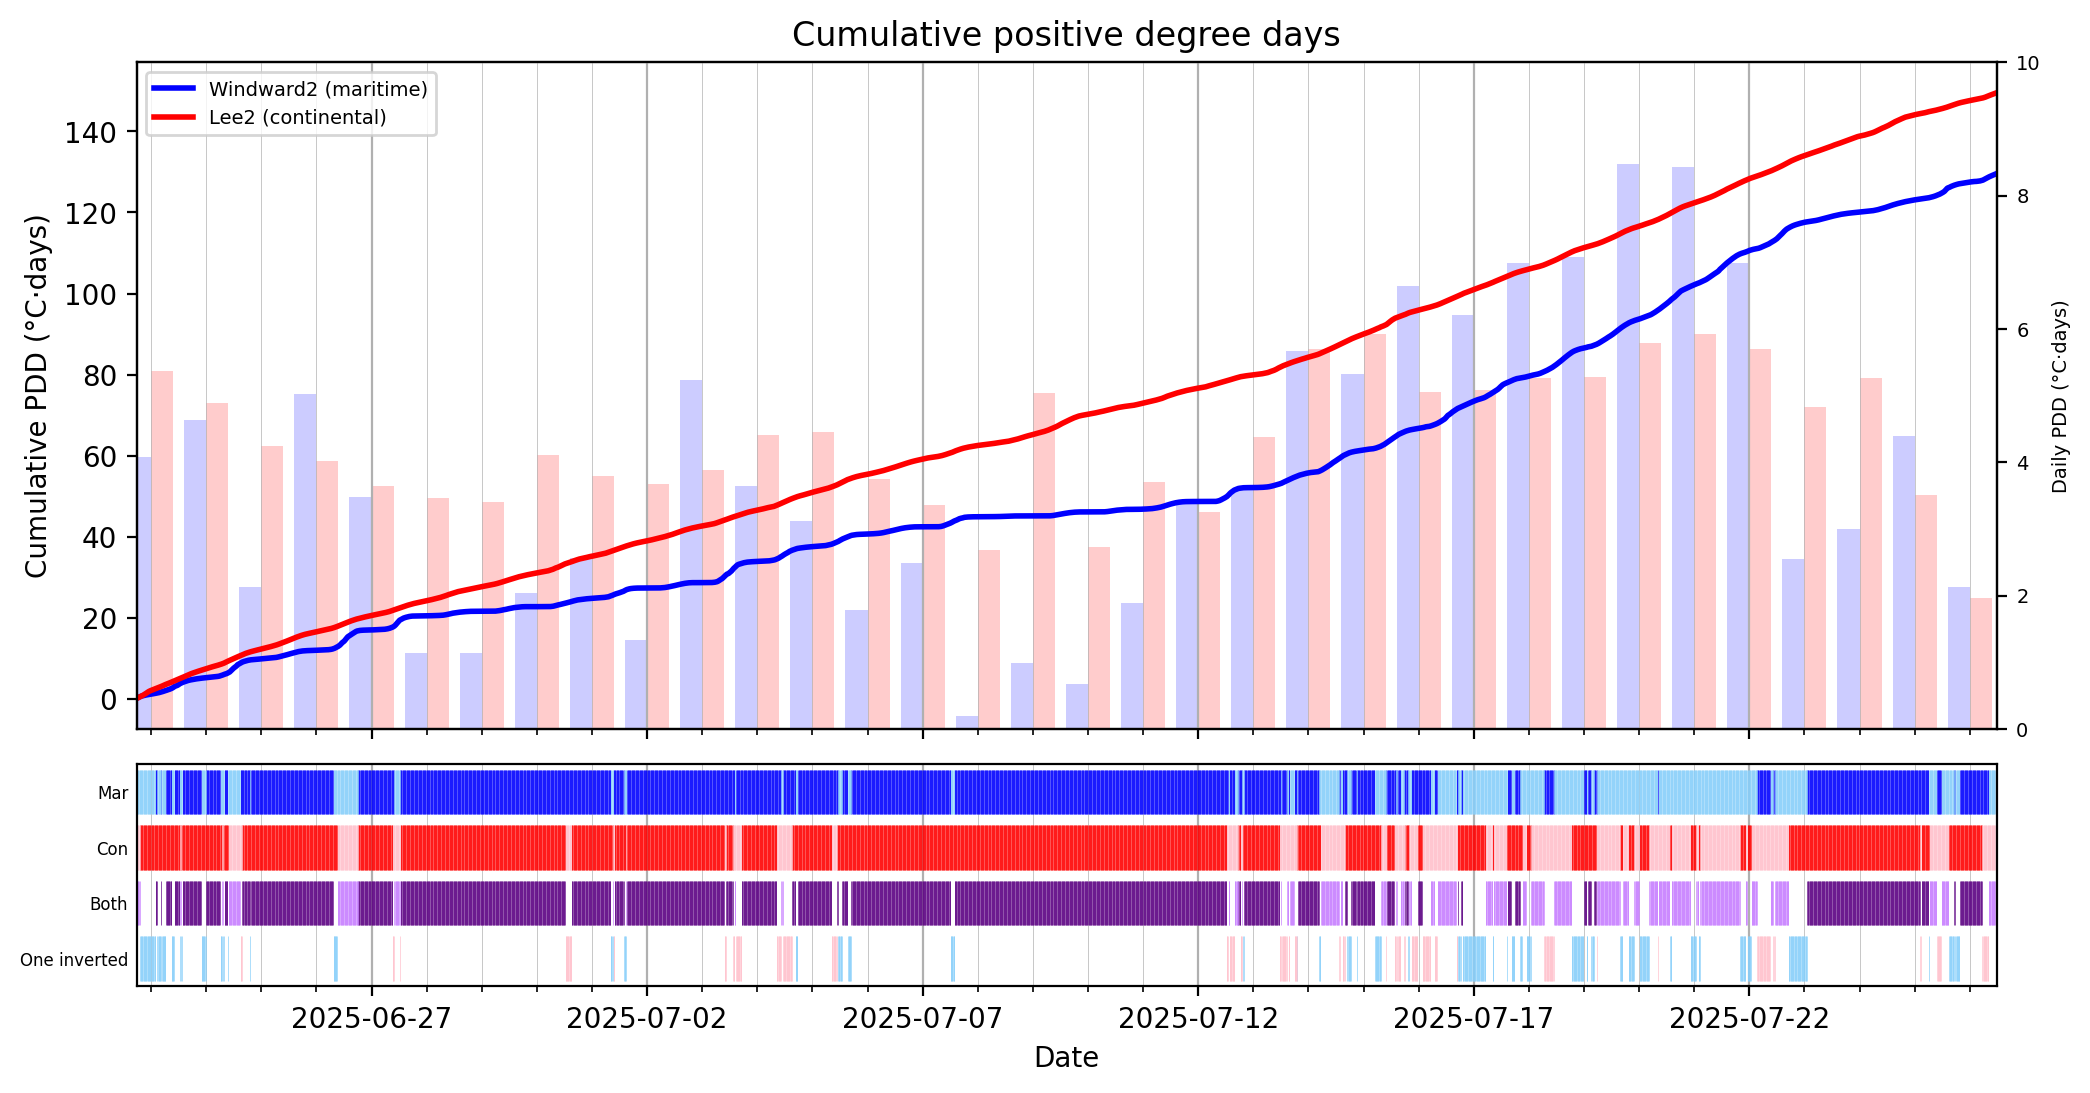

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# Configure Butterworth filter for plotting (lapse rate only)
FILTER_ORDER = 4
FILTER_LOWER = None  # Low-pass filter only
FILTER_UPPER = 1 / (2 * 60 * 60)  # 2 hr cutoff
FILTER_FS = 1 / (300 * 3)  # For 15-min data

# --- Cumulative positive degree days from raw temp ---
mar_temp = select_sensors(ds["temp_c"], site_id="A07")
con_temp = select_sensors(ds["temp_c"], site_id="Lee2")

# Clamp negatives to 0, scale to days (96 x 15-min intervals per day)
mar_pdd_vals = np.maximum(mar_temp.values, 0) / 96
con_pdd_vals = np.maximum(con_temp.values, 0) / 96

# --- Save PDD timeseries as data variables in the xarray dataset ---
ds["mar_pdd"] = xr.DataArray(
    mar_pdd_vals,
    coords=mar_temp.coords,
    dims=mar_temp.dims,
    attrs={"long_name": "Maritime instantaneous PDD", "units": "°C·days per timestep"},
)
ds["con_pdd"] = xr.DataArray(
    con_pdd_vals,
    coords=con_temp.coords,
    dims=con_temp.dims,
    attrs={"long_name": "Continental instantaneous PDD", "units": "°C·days per timestep"},
)

# --- Resample instantaneous PDD to daily sums for bar plot ---
times = pd.DatetimeIndex(ds.datetime.values)

mar_pdd_daily = pd.Series(mar_pdd_vals.squeeze(), index=times).resample("1D").sum()
con_pdd_daily = pd.Series(con_pdd_vals.squeeze(), index=times).resample("1D").sum()

# --- Filter both lapse rate series ---
maritime_lr = ds["maritime_lapse_rate"].copy()
continental_lr = ds["continental_lapse_rate"].copy()

# --- Build figure with 2 subplots ---
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    dpi=200,
    figsize=(12, 6),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True,
)
fig.subplots_adjust(hspace=0.08)

# ---- Top subplot: cumulative PDD lines + daily PDD bars on twin axis ----
ax1.set_xlim(ds.datetime[0], ds.datetime[-1])

# Twin axis for daily bars (behind lines)
ax1b = ax1.twinx()

bar_width = 0.4  # days
bar_offset = pd.Timedelta(hours=4.8)

ax1b.bar(
    mar_pdd_daily.index - bar_offset,
    mar_pdd_daily.values,
    width=bar_width,
    align="center",
    color="blue",
    alpha=0.2,
    label="_nolegend_",
)
ax1b.bar(
    con_pdd_daily.index + bar_offset,
    con_pdd_daily.values,
    width=bar_width,
    align="center",
    color="red",
    alpha=0.2,
    label="_nolegend_",
)
ax1b.set_ylabel("Daily PDD (°C·days)", fontsize=7)
ax1b.tick_params(axis="y", labelsize=7)
ax1b.set_ylim(0, 10)


# Cumulative lines on top
ax1.plot(ds.datetime, mar_pdd_vals.cumsum(), lw=2, c="blue", label="Windward2 (maritime)")
ax1.plot(ds.datetime, con_pdd_vals.cumsum(), lw=2, c="red", label="Lee2 (continental)")

ax1.set_zorder(ax1b.get_zorder() + 1)  # lines in front of bars
ax1.patch.set_visible(False)  # let bars show through

ax1.legend(fontsize=7, loc="upper left")
ax1.grid(which="both", axis="x")
ax1.xaxis.set_major_locator(mpl.dates.DayLocator(interval=5))
ax1.xaxis.set_minor_locator(mpl.dates.DayLocator(interval=1))
ax1.grid(which="minor", lw=0.25)
ax1.set_title("Cumulative positive degree days")
ax1.set_ylabel("Cumulative PDD (°C·days)")
ax1.set_xlabel("")

# ---- Bottom subplot: eventplot (unchanged) ----
ax2.set_xlim(ds.datetime[0], ds.datetime[-1])

mar_pos = maritime_lr > 0
mar_neg = maritime_lr < 0
con_pos = continental_lr > 0
con_neg = continental_lr < 0
both_pos = mar_pos & con_pos
both_neg = mar_neg & con_neg
mar_inv_only = mar_pos & ~con_pos
con_inv_only = con_pos & ~mar_pos

length = 0.8
all_pairs = [
    ("One inverted", mar_inv_only, "lightskyblue", con_inv_only, "pink"),
    ("Both", both_neg, "#5B0082", both_pos, "#C77DFF"),
    ("Con", con_neg, "red", con_pos, "pink"),
    ("Mar", mar_neg, "blue", mar_pos, "lightskyblue"),
]
offsets = [i + 0.5 for i in range(len(all_pairs))]

for i, (label, mask_a, color_a, mask_b, color_b) in enumerate(all_pairs):
    ax2.eventplot(
        ds.datetime[mask_a.values], lineoffsets=offsets[i], linelengths=length,
        lw=0.3, alpha=0.8, colors=color_a,
    )
    ax2.eventplot(
        ds.datetime[mask_b.values], lineoffsets=offsets[i], linelengths=length,
        lw=0.3, alpha=0.8, colors=color_b,
    )

row_labels = [label for label, *_ in all_pairs]
ax2.set_ylim(0, len(all_pairs))
ax2.set_yticks(offsets)
ax2.set_yticklabels(row_labels, fontsize=6)
ax2.tick_params(axis="y", length=0, pad=3)
ax2.grid(which="both", axis="x")
ax2.xaxis.set_major_locator(mpl.dates.DayLocator(interval=5))
ax2.xaxis.set_minor_locator(mpl.dates.DayLocator(interval=1))
ax2.grid(which="minor", lw=0.25)
ax2.set_xlabel("Date")

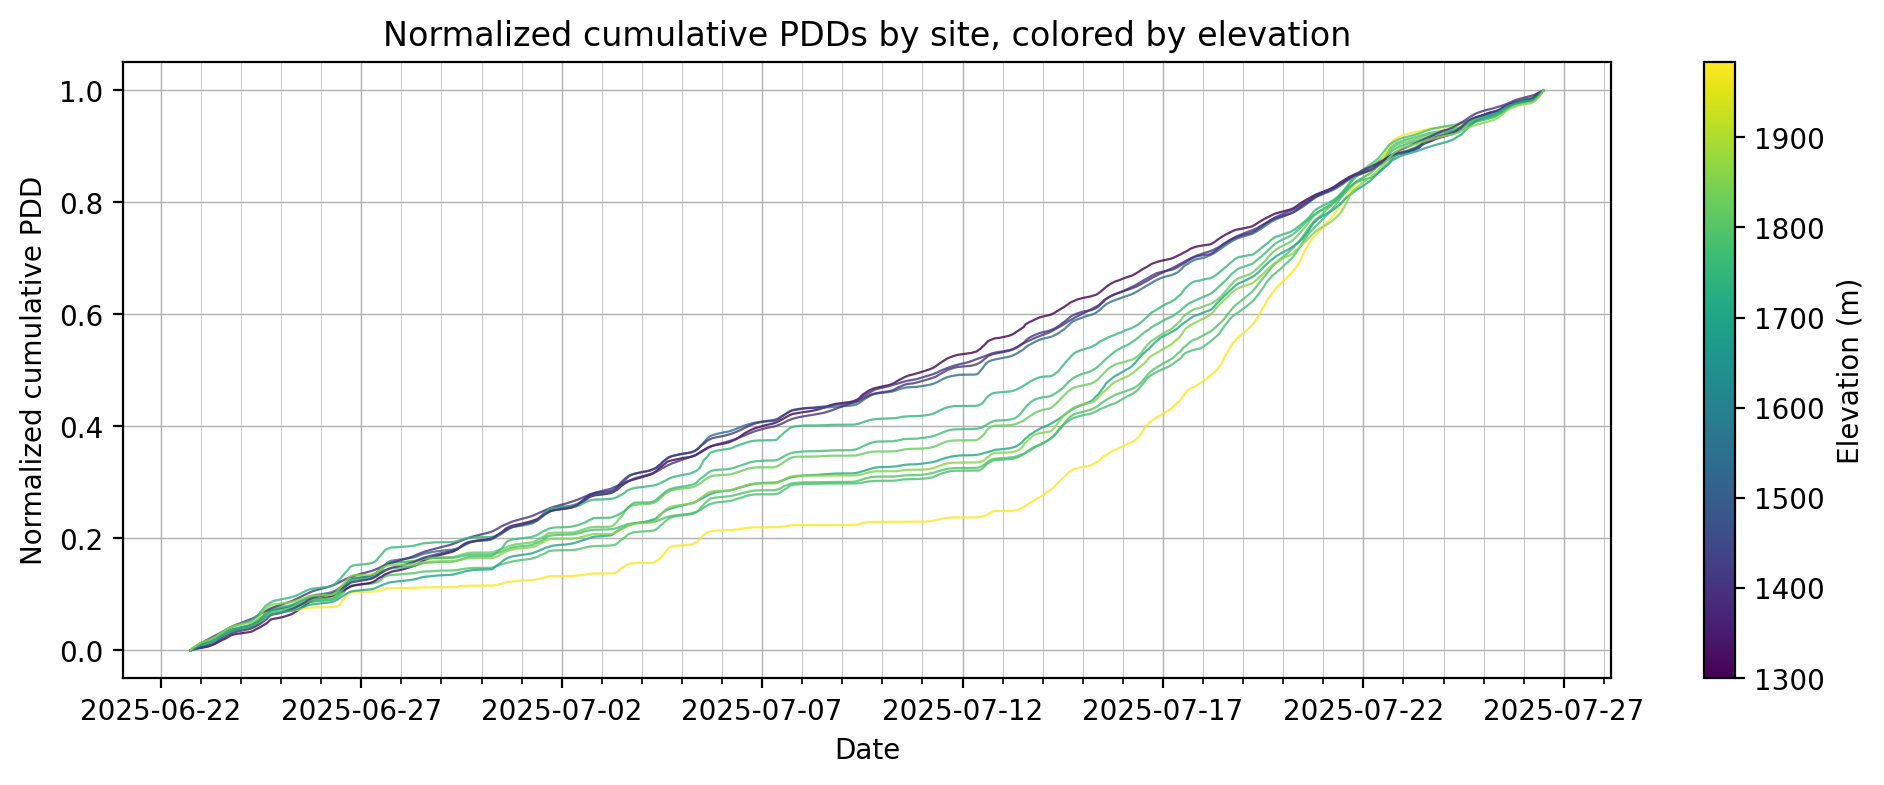

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(dpi=200, figsize=(12, 4))

elevations = ds["temp_c"].elevation.values
norm = mpl.colors.Normalize(vmin=np.nanmin(elevations), vmax=np.nanmax(elevations))
cmap = mpl.cm.viridis

for i in range(ds["temp_c"].sizes["sensor_idx"]):
    temp = ds["temp_c"].isel(sensor_idx=i).values
    pdd_cumsum = np.nancumsum(np.maximum(temp, 0) / 96)

    pdd_min, pdd_max = pdd_cumsum.min(), pdd_cumsum.max()
    if pdd_max > pdd_min:
        pdd_norm = (pdd_cumsum - pdd_min) / (pdd_max - pdd_min)
    else:
        continue

    elev = elevations[i]
    ax.plot(ds.datetime, pdd_norm, lw=0.8, alpha=0.8, c=cmap(norm(elev)))

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=ax, label="Elevation (m)")

ax.set_ylabel("Normalized cumulative PDD")
ax.set_xlabel("Date")
ax.set_title("Normalized cumulative PDDs by site, colored by elevation")
ax.xaxis.set_major_locator(mpl.dates.DayLocator(interval=5))
ax.xaxis.set_minor_locator(mpl.dates.DayLocator(interval=1))
ax.grid(which="minor", lw=0.25)
ax.grid(which="major", lw=0.5)

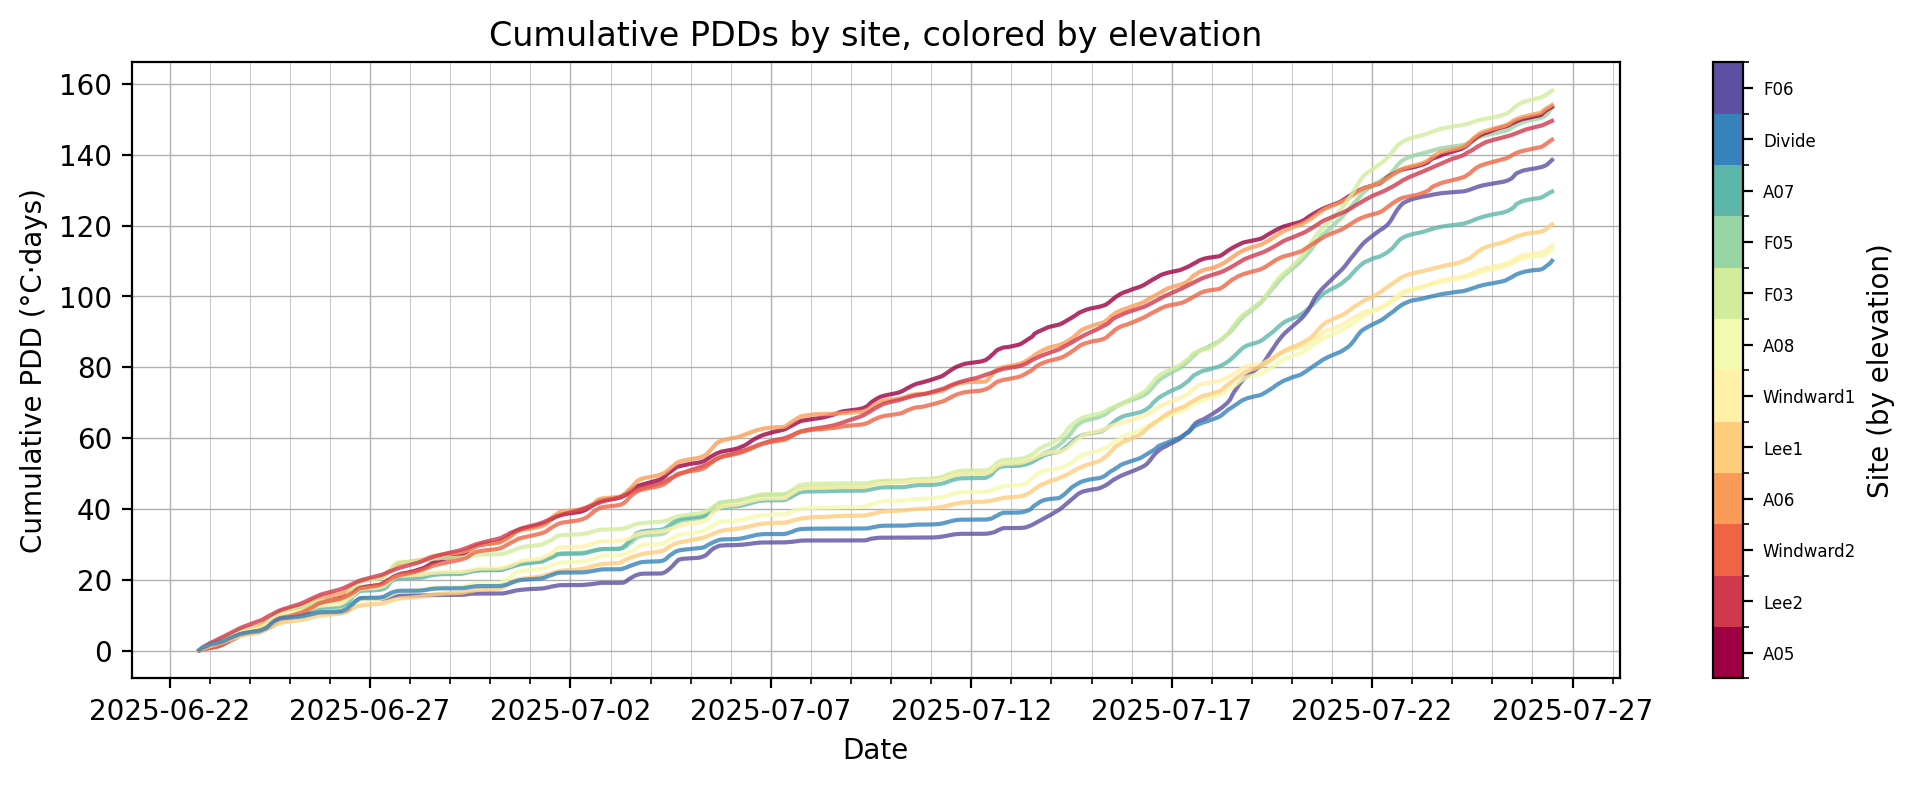

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(dpi=200, figsize=(12, 4))

elevations = ds["temp_c"].elevation.values
site_ids = ds["temp_c"].site_id.values

sort_idx = np.argsort(elevations)
rank = np.empty_like(sort_idx)
rank[sort_idx] = np.arange(len(sort_idx))

n = len(site_ids)

# Build a listed colormap sampled at the same fractions as the lines
fractions = np.linspace(0, 1, n)
colors = mpl.cm.Spectral(fractions)
listed_cmap = mpl.colors.ListedColormap(colors)
boundaries = np.arange(n + 1)
norm = mpl.colors.BoundaryNorm(boundaries, ncolors=n)

for i in range(ds["temp_c"].sizes["sensor_idx"]):
    temp = ds["temp_c"].isel(sensor_idx=i).values
    pdd_cumsum = np.nancumsum(np.maximum(temp, 0) / 96)
    ax.plot(ds.datetime, pdd_cumsum, lw=1.5, alpha=0.8, c=colors[rank[i]])

sm = mpl.cm.ScalarMappable(cmap=listed_cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax, ticks=np.arange(n) + 0.5)
cbar.ax.set_yticklabels(site_ids[sort_idx], fontsize=6)
cbar.set_label("Site (by elevation)")

ax.set_ylabel("Cumulative PDD (°C·days)")
ax.set_xlabel("Date")
ax.set_title("Cumulative PDDs by site, colored by elevation")
ax.xaxis.set_major_locator(mpl.dates.DayLocator(interval=5))
ax.xaxis.set_minor_locator(mpl.dates.DayLocator(interval=1))
ax.grid(which="minor", lw=0.25)
ax.grid(which="major", lw=0.5)

Text(0.5, 1.0, 'Periods where 1m sensor is colder than 2m sensor')

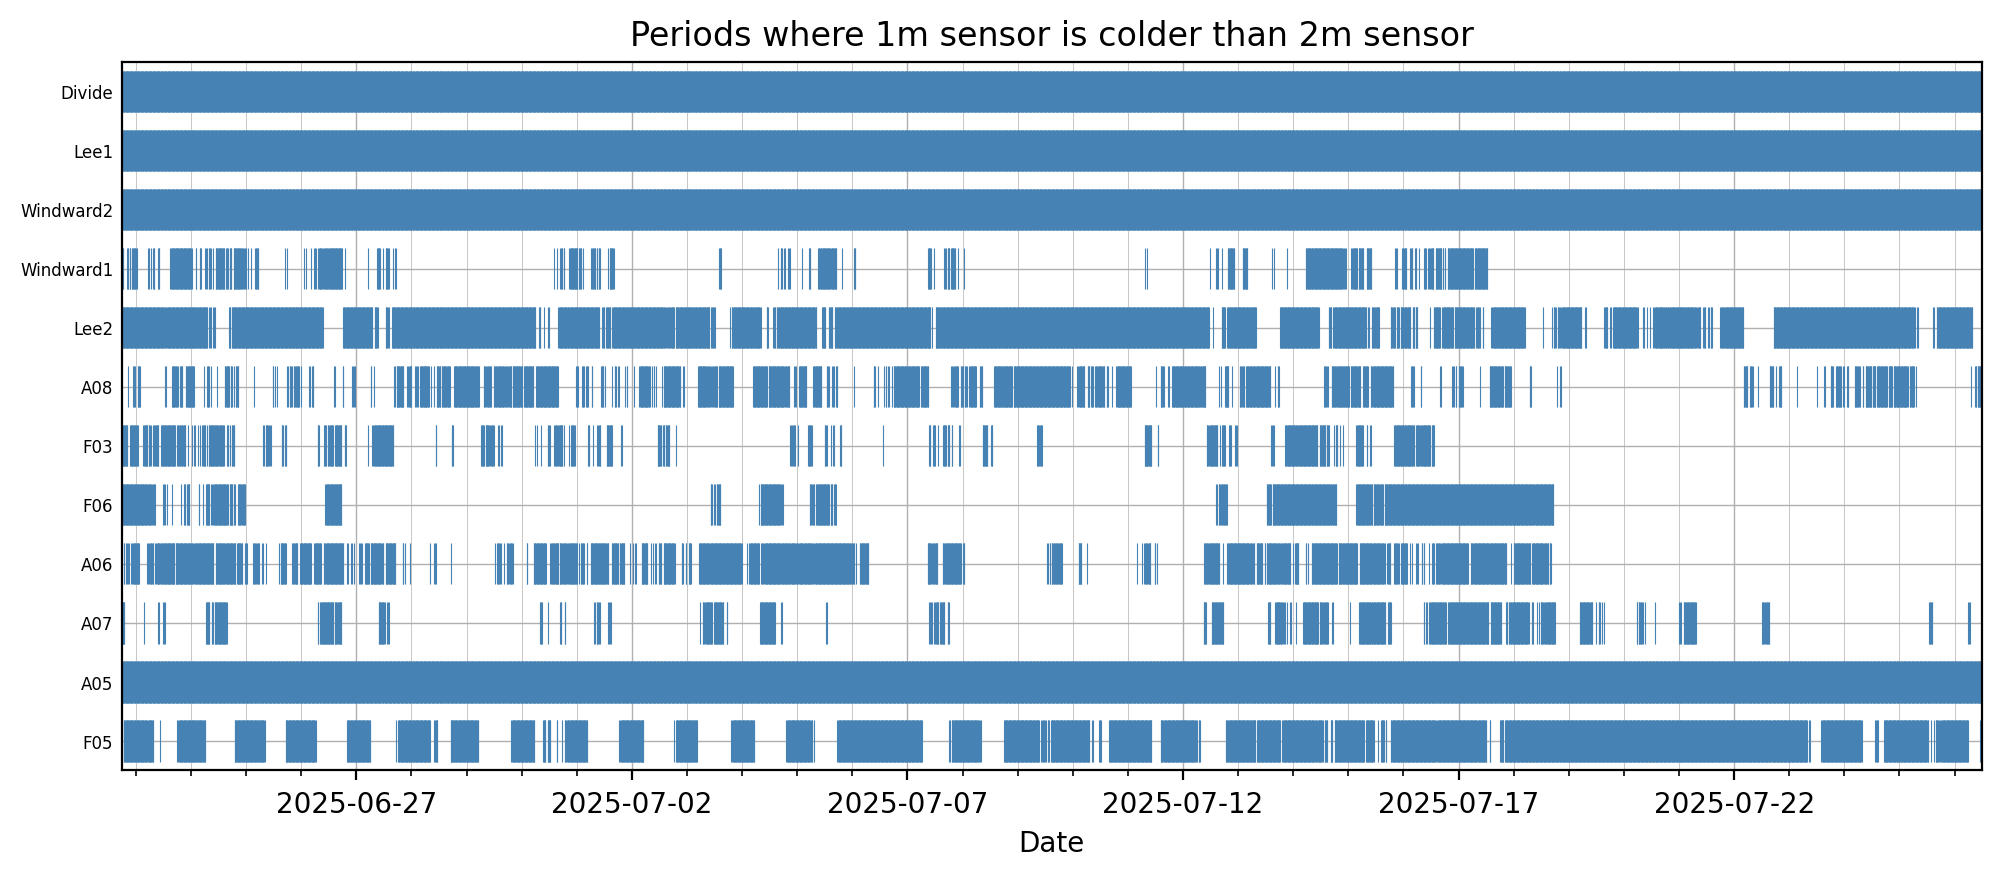

In [ ]:
site_ids = ds.site_id.values
n_sites = len(site_ids)

fig, ax = plt.subplots(dpi=200, figsize=(12, n_sites * 0.3 + 1))

for i, site in enumerate(site_ids):
    mask = ds.sel(sensor_idx=ds.sensor_idx[ds.site_id == site]).inversion.values.squeeze()
    mask = np.asarray(mask, dtype=bool)
    times = ds.datetime.values[mask]
    if len(times):
        ax.eventplot(times, lineoffsets=i + 0.5, linelengths=0.7, lw=0.4, colors="steelblue")

ax.set_yticks(np.arange(n_sites) + 0.5)
ax.set_yticklabels(site_ids, fontsize=6)
ax.tick_params(axis="y", length=0, pad=3)
ax.set_ylim(0, n_sites)
ax.set_xlim(ds.datetime[0], ds.datetime[-1])
ax.xaxis.set_major_locator(mpl.dates.DayLocator(interval=5))
ax.xaxis.set_minor_locator(mpl.dates.DayLocator(interval=1))
ax.grid(which="minor", lw=0.25)
ax.grid(which="major", lw=0.5)
ax.set_xlabel("Date")
ax.set_title("Periods where 1m sensor is colder than 2m sensor")